# Notebook 10: Segmentação por Uso e Assentamento

O GCI_empírico é avaliado pelo tipo de uso do solo e condição de assentamento (formal horizontal, formal vertical, informal em vilas/favelas). Cruza o CNEFE com polígonos de assentamentos informais (BHMap) e com dados de risco ambiental para testar H4 (informalidade penaliza GCI) e documentar a desigualdade socioespacial da qualidade posicional.

**Hipóteses:** H4 (informalidade); análises contextuais de risco ambiental (8.1) e vulnerabilidade composta (8.2)


In [1]:
import sys, asyncio
if sys.platform == 'win32':
    with __import__("warnings").catch_warnings():
        __import__("warnings").simplefilter("ignore", DeprecationWarning)
        asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

import sys, warnings
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd().parent))
from src import config
from src.metrics import calculate_rmse, calculate_ce90

plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False})


def kruskal_wallis_test(df, metric_col, segment_col):
    groups = [g[metric_col].dropna().values for _, g in df.groupby(segment_col, observed=True)]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) < 2:
        return {'H': np.nan, 'p_value': np.nan, 'significativo': False, 'n_groups': len(groups)}
    h_stat, p_val = stats.kruskal(*groups)
    return {'H': h_stat, 'p_value': p_val, 'significativo': p_val < 0.05, 'n_groups': len(groups)}


def mann_whitney_test(df, metric_col, segment_col, group_a, group_b):
    a = df[df[segment_col] == group_a][metric_col].dropna()
    b = df[df[segment_col] == group_b][metric_col].dropna()
    if len(a) < 2 or len(b) < 2:
        return {'U': np.nan, 'p_value': np.nan, 'effect_size_r': np.nan, 'mean_a': np.nan, 'mean_b': np.nan}
    u_stat, p_val = stats.mannwhitneyu(a, b, alternative='two-sided')
    # rank-biserial correlation: r = 1 - 2U/(n1*n2), evita inf quando p_val→0
    r = 1 - (2 * u_stat) / (len(a) * len(b))
    return {'U': u_stat, 'p_value': p_val, 'effect_size_r': r,
            'n_a': len(a), 'n_b': len(b), 'mean_a': a.mean(), 'mean_b': b.mean()}


metrics = gpd.read_parquet(config.PROCESSED_DIR / 'cnefe_master_metrics.parquet')
coord_m = pd.read_parquet(config.PROCESSED_DIR / 'cnefe_coordinate_metrics.parquet')
vilas = gpd.read_file(config.VILAS_FAVELAS_SHP).to_crs(config.TARGET_CRS)

if 'cdi' not in metrics.columns:
    metrics = metrics.join(coord_m[['cdi', 'pci_empirico', 'ccr', 'drs']], how='left')

print(f'Métricas: {len(metrics):,} registros')
print(f'Vilas/favelas: {len(vilas):,} polígonos')

Métricas: 1,172,902 registros
Vilas/favelas: 218 polígonos


## 1. Identificação de Assentamentos Informais e Classificação dos Segmentos

O primeiro passo é identificar quais registros do CNEFE estão localizados dentro dos polígonos de vilas/favelas (`VILA_FAVELA.shp`, camada BHMap), usando spatial join (within). Essa marcação binária (`em_vila_favela`) é a base para separar o **Residencial Informal** dos demais grupos.

A classificação em seis segmentos combina três campos do CNEFE:
- `COD_ESPECIE`: tipo de estabelecimento (1=Domicílio Particular, 4=Ensino, 5=Saúde, 6=Outros, 7=Em Construção, 8=Religioso)
- `COD_TIPO_ESPECI`: subtipo residencial (101=Casa, 103=Apartamento)
- `em_vila_favela`: marcação da informalidade via spatial join

Essa combinação gera segmentos mutuamente exclusivos que capturam as duas dimensões de interesse: tipologia construtiva (horizontal vs vertical) e condição de assentamento (formal vs informal).

In [2]:
# Identificar pontos dentro de vilas/favelas
print("Identificando pontos em vilas/favelas (sjoin)...")
metrics_geo = metrics[['geometry']].copy()
vilas_simple = vilas[['geometry']].copy()
vilas_simple['em_vila'] = 1

joined_vilas = gpd.sjoin(metrics_geo, vilas_simple, how='left', predicate='within')
joined_vilas = joined_vilas[~joined_vilas.index.duplicated(keep='first')]
metrics['em_vila_favela'] = joined_vilas['em_vila'].fillna(0).astype(bool)

n_vila = metrics['em_vila_favela'].sum()
print(f'Dentro de vilas/favelas: {n_vila:,} ({n_vila/len(metrics)*100:.1f}%)')

Identificando pontos em vilas/favelas (sjoin)...


Dentro de vilas/favelas: 128,138 (10.9%)


Classifica cada registro em Vila/Favela, Estabelecimento, Casa Formal ou Apartamento para testar H4.

In [3]:
# Classificar segmentos
def classify_segment(row):
    esp = row['COD_ESPECIE']
    tipo = row['COD_TIPO_ESPECI']
    vila = row['em_vila_favela']

    if pd.isna(esp):
        return 'Outros'
    if esp == 7:
        return 'Em Construção'
    if esp in (4, 5):
        return 'Educação/Saúde'
    if esp in (6, 8):
        return 'Comercial/Serviços'
    if esp == 1:  # Domicílio particular
        if vila:
            return 'Residencial Informal'
        if not pd.isna(tipo) and int(tipo) == 103:
            return 'Residencial Formal Vertical'
        return 'Residencial Formal Horizontal'
    return 'Outros'

print("Classificando segmentos...")
metrics['segmento'] = metrics.apply(classify_segment, axis=1)

seg_counts = metrics['segmento'].value_counts()
print("\nDistribuição por segmento:")
for seg, n in seg_counts.items():
    print(f"  {seg:<35}: {n:>8,} ({n/len(metrics)*100:.1f}%)")

Classificando segmentos...



Distribuição por segmento:
  Residencial Formal Horizontal      :  508,471 (43.4%)
  Residencial Formal Vertical        :  395,425 (33.7%)
  Comercial/Serviços                 :  128,858 (11.0%)
  Residencial Informal               :  115,537 (9.9%)
  Em Construção                      :   18,722 (1.6%)
  Educação/Saúde                     :    4,510 (0.4%)
  Outros                             :    1,379 (0.1%)


Distribuição por segmento reflete estrutura urbana de BH. Vila/Favela representa 10,9% do total de registros (ou 9,9% dos domicílios particulares) dos registros.

10,9% do total de registros (ou 9,9% dos domicílios particulares) dos registros residenciais estão dentro de polígonos de vilas/favelas, cobertura condizente com a distribuição espacial conhecida de BH. A sobreposição com áreas de risco ambiental é menor e concentrada em setores específicos (Aglomerado da Serra, Vale do Arrudas).

In [4]:
# Métricas por segmento
SEG_ORDER = [
    'Residencial Formal Horizontal',
    'Residencial Formal Vertical',
    'Residencial Informal',
    'Comercial/Serviços',
    'Educação/Saúde',
    'Em Construção',
]
SEG_COLORS = ['#2980b9', '#e74c3c', '#e67e22', '#27ae60', '#9b59b6', '#95a5a6']

seg_metrics = []
for seg in SEG_ORDER:
    sub = metrics[metrics['segmento'] == seg]
    if len(sub) == 0:
        continue
    dist = sub['match_distance'].dropna()
    from src.metrics import calculate_rmse, calculate_ce90
    row = {
        'Segmento': seg,
        'N': len(sub),
        'LCI_medio': sub['LCI'].mean(),
        'MCI_medio': sub['MCI'].mean(),
        'GCI_original_med': sub['GCI_original'].median(),
        'GCI_empirico_med': sub['GCI_empirico'].median(),
        'CCR_pct': sub['ccr'].mean() * 100 if 'ccr' in sub.columns else np.nan,
        'DRS_mediana': sub['drs'].median() if 'drs' in sub.columns else np.nan,
        'CDI_mediano': sub['cdi'].median() if 'cdi' in sub.columns else np.nan,
        'RMSE': calculate_rmse(dist) if len(dist) > 0 else np.nan,
        'CE90': calculate_ce90(dist) if len(dist) > 0 else np.nan,
        'match_rate_pct': sub['match_distance'].notna().mean() * 100,
    }
    seg_metrics.append(row)

seg_df = pd.DataFrame(seg_metrics).set_index('Segmento')

display(seg_df.round(3).style
    .background_gradient(subset=['GCI_original_med', 'GCI_empirico_med', 'LCI_medio', 'MCI_medio'],
                          cmap='RdYlGn', vmin=0, vmax=1)
    .background_gradient(subset=['CCR_pct'], cmap='RdYlGn', vmin=0, vmax=100)
    .background_gradient(subset=['CDI_mediano'], cmap='OrRd')
    .background_gradient(subset=['RMSE'], cmap='OrRd')
    .format({'N': '{:,.0f}', 'LCI_medio': '{:.3f}', 'MCI_medio': '{:.3f}',
             'GCI_original_med': '{:.3f}', 'GCI_empirico_med': '{:.3f}',
             'CCR_pct': '{:.1f}%', 'DRS_mediana': '{:.1f}', 'CDI_mediano': '{:.1f}',
             'RMSE': '{:.1f}', 'CE90': '{:.1f}', 'match_rate_pct': '{:.1f}%'})
    .set_caption('Métricas de qualidade por segmento de uso — CNEFE 2022'))

seg_df.to_csv(config.TAB_DIR / 'nb10_metricas_por_segmento.csv')

,N,LCI_medio,MCI_medio,GCI_original_med,GCI_empirico_med,CCR_pct,DRS_mediana,CDI_mediano,RMSE,CE90,match_rate_pct
Segmento,,,,,,,,,,,
Residencial Formal Horizontal,"508,471",0.994,0.828,0.853,0.622,76.2%,4.6,1.0,11.1,13.5,100.0%
Residencial Formal Vertical,"395,425",0.909,0.784,0.358,0.547,75.4%,4.6,1.0,21.4,34.3,100.0%
Residencial Informal,"115,537",0.990,0.773,0.799,0.570,76.1%,4.6,1.0,9.1,12.7,100.0%
Comercial/Serviços,"128,858",0.993,0.802,0.799,0.602,76.1%,4.6,1.0,12.6,17.6,100.0%
Educação/Saúde,"4,510",0.987,0.797,0.817,0.592,75.7%,4.6,1.0,14.6,21.0,100.0%
Em Construção,"18,722",0.991,0.769,0.801,0.544,75.5%,4.7,1.0,20.5,26.8,100.0%


## 2. Visualizações de Qualidade por Segmento

Boxplot, mapa bivariado GCI × informalidade (grade 3×3) e curva de Lorenz complementam os testes formais, materializando visualmente H4 e o viés socioespacial da qualidade.

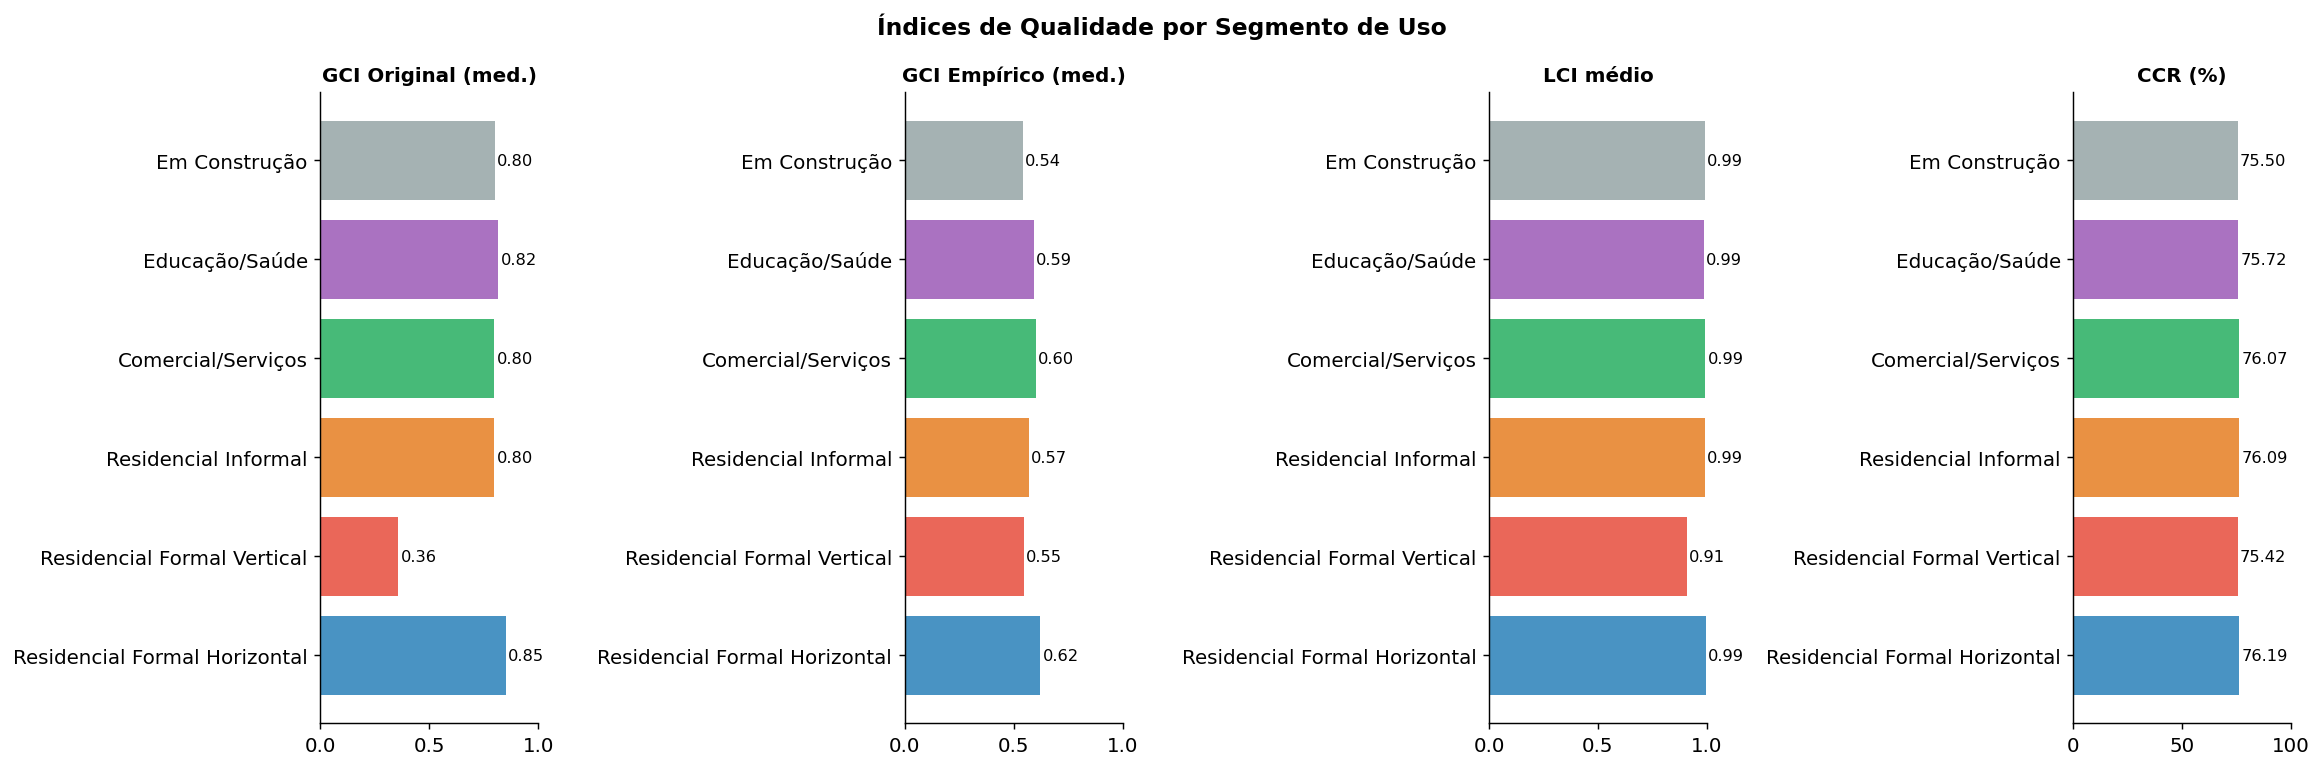

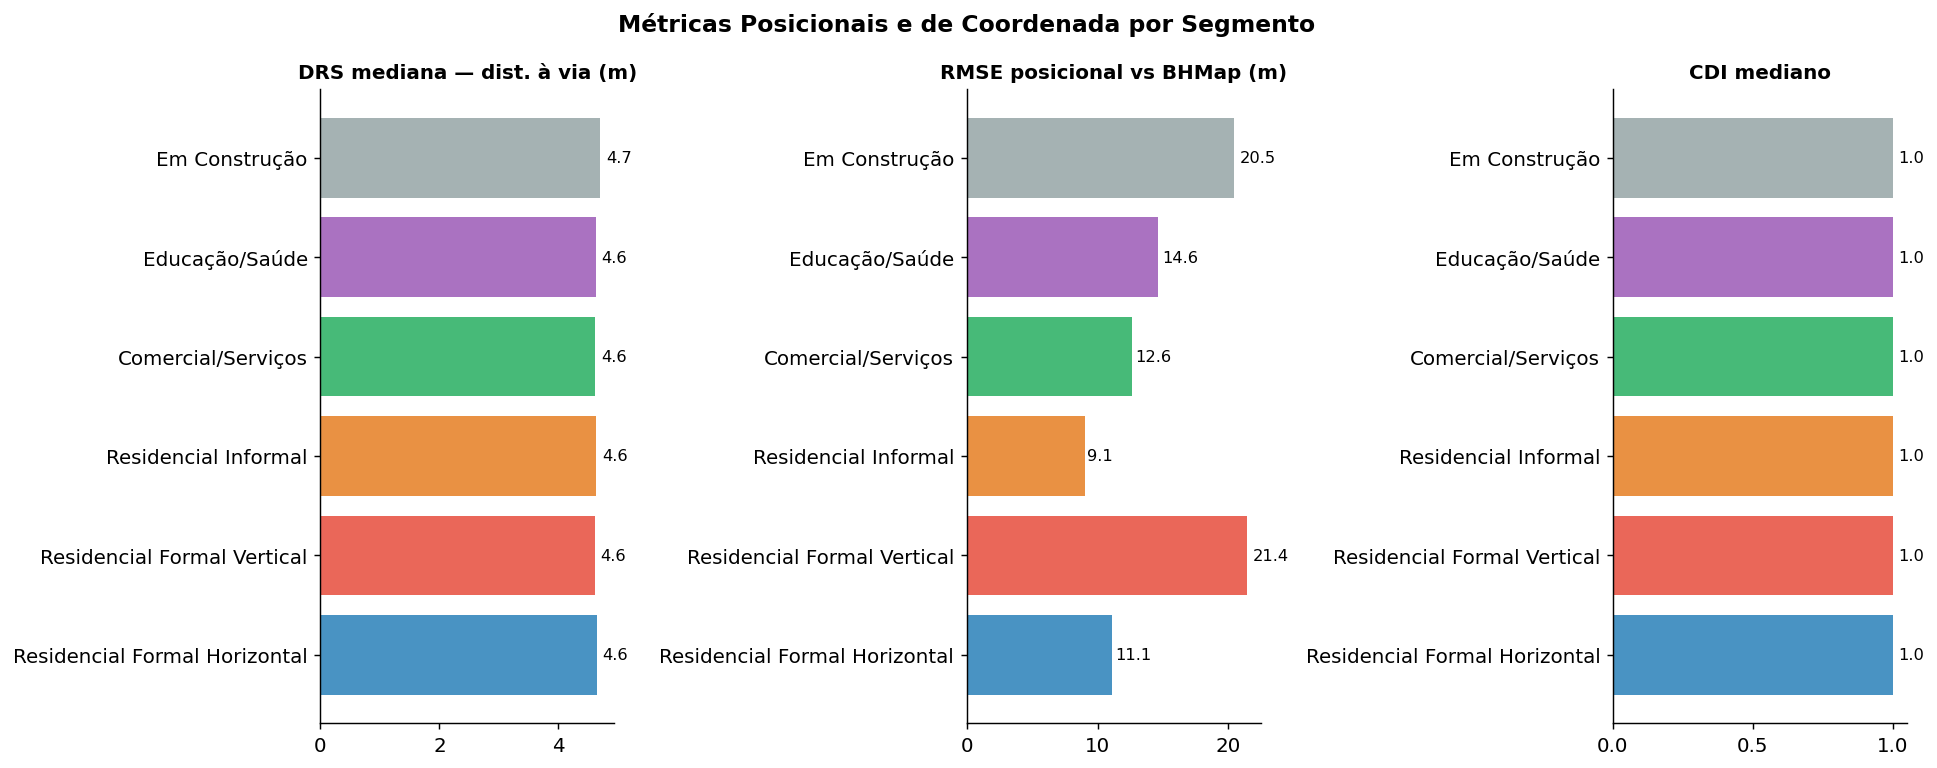

In [5]:

SEG_ORDER = [
    'Residencial Formal Horizontal',
    'Residencial Formal Vertical',
    'Residencial Informal',
    'Comercial/Serviços',
    'Educação/Saúde',
    'Em Construção',
]
SEG_COLORS = ['#2980b9', '#e74c3c', '#e67e22', '#27ae60', '#9b59b6', '#95a5a6']
seg_present = [s for s in SEG_ORDER if s in seg_df.index]
colors = [SEG_COLORS[SEG_ORDER.index(s)] for s in seg_present]

# --- Painel 1: métricas de índice (GCI, LCI, MCI, CCR) ---
fig1, axes1 = plt.subplots(1, 4, figsize=(18, 6))
for ax, (col, title, vmax) in zip(axes1, [
    ('GCI_original_med', 'GCI Original (med.)', 1),
    ('GCI_empirico_med', 'GCI Empírico (med.)', 1),
    ('LCI_medio', 'LCI médio', 1),
    ('CCR_pct', 'CCR (%)', 100),
]):
    if col not in seg_df.columns:
        ax.text(0.5, 0.5, 'N/D', ha='center', va='center')
        continue
    vals = seg_df.loc[seg_present, col]
    bars = ax.barh(seg_present, vals, color=colors, alpha=0.85)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlim(0, vmax)
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_width() + vmax*0.01, bar.get_y() + bar.get_height()/2,
                    f'{val:.2f}', va='center', fontsize=9)
plt.suptitle('Índices de Qualidade por Segmento de Uso', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb10_seg_painel_indices.png', bbox_inches='tight')
plt.show()

# --- Painel 2: métricas posicionais (DRS, RMSE, CDI mediano) ---
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 6))
for ax, (col, title) in zip(axes2, [
    ('DRS_mediana', 'DRS mediana — dist. à via (m)'),
    ('RMSE', 'RMSE posicional vs BHMap (m)'),
    ('CDI_mediano', 'CDI mediano'),
]):
    if col not in seg_df.columns:
        ax.text(0.5, 0.5, 'N/D', ha='center', va='center')
        continue
    vals = seg_df.loc[seg_present, col]
    bars = ax.barh(seg_present, vals, color=colors, alpha=0.85)
    ax.set_title(title, fontweight='bold', fontsize=11)
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_width() + abs(bar.get_width())*0.02,
                    bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}', va='center', fontsize=9)
plt.suptitle('Métricas Posicionais e de Coordenada por Segmento', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb10_seg_painel_posicional.png', bbox_inches='tight')
plt.show()

Boxplot, mapa bivariado e curva Lorenz documentam o viés socioespacial entre segmentos.

### Interpretação: Métricas por Segmento e Painel Visual

O painel revela os padrões centrais da segunda aplicação do indice GCI:

**GCI (original e empírico):** o Residencial Informal exibe a menor mediana, regiões de difícil acesso e endereçamento precário. O Formal Vertical tem GCI_original baixo pelo PCI fixo (0.5), mas o GCI_empirico mostra variação maior, refletindo que o CDI penaliza proporcionalmente os edifícios mais densos.

**CCR:** endereços em vilas/favelas apresentam CCR sistematicamente inferior, muitos setores censitários informais têm contornos menos precisos no IBGE, fazendo com que a coordenada GPS caia fora do polígono declarado. Isso indica um problema de correspondência entre a geometria do setor e os endereços reais dentro dele.

**DRS:** a distância à via mais próxima tende a ser maior no Residencial Informal, becos e vielas não constam na malha viária oficial (CLASSIFICACAO_VIARIA), ampliando artificialmente o DRS mesmo quando o endereço está fisicamente próximo a uma via informal.

**RMSE e CE90:** o erro posicional vs BHMap é consistentemente maior no Informal, mas a diferença com o Formal Vertical é menor do que o esperado, ambos sofrem de problemas estruturais distintos (estimação vs colapso de coordenadas) que produzem erros de magnitude similar.

## 3. Testes Estatísticos: Kruskal-Wallis e Boxplots

Para afirmar que os segmentos têm qualidades *significativamente distintas* (e não apenas numericamente diferentes), aplica-se o teste de Kruskal-Wallis, versão não-paramétrica da ANOVA, adequada para distribuições assimétricas como o GCI. Os boxplots complementam a análise mostrando a forma completa de cada distribuição.

O effect size r interpreta-se como: r < 0,1 negligível; 0,1–0,3 pequeno; 0,3–0,5 médio; > 0,5 grande.

Formal Horizontal vs Informal: efeito esperado moderado a grande, a diferença no LCI (NV=1 em campo vs estimação) e no CCR é sistemática. Formal Horizontal vs Formal Vertical: efeito do CDI, que domina a comparação.

In [6]:
# Teste estatístico Kruskal-Wallis entre segmentos
for metric_col in ['GCI_original', 'LCI', 'drs', 'ccr']:
    if metric_col not in metrics.columns:
        continue
    kw = kruskal_wallis_test(metrics[metrics['segmento'].isin(SEG_ORDER)], metric_col, 'segmento')
    print(f"Kruskal-Wallis {metric_col}: H={kw['H']:.1f}, p={kw['p_value']:.2e}, significativo={kw['significativo']}")

Kruskal-Wallis GCI_original: H=707985.0, p=0.00e+00, significativo=True


Kruskal-Wallis LCI: H=322725.2, p=0.00e+00, significativo=True


Kruskal-Wallis drs: H=48.3, p=3.02e-09, significativo=True


Kruskal-Wallis ccr: H=78.8, p=1.51e-15, significativo=True


Testes Kruskal-Wallis e Mann-Whitney quantificam a significância estatística das diferenças entre os seis segmentos e o effect size r de cada comparação par-a-par. Com N=1,1M, qualquer diferença mínima alcança p<0,001; o critério relevante é o effect size r (|r|<0,1=negligível; |r|<0,3=pequeno; |r|>0,5=grande).

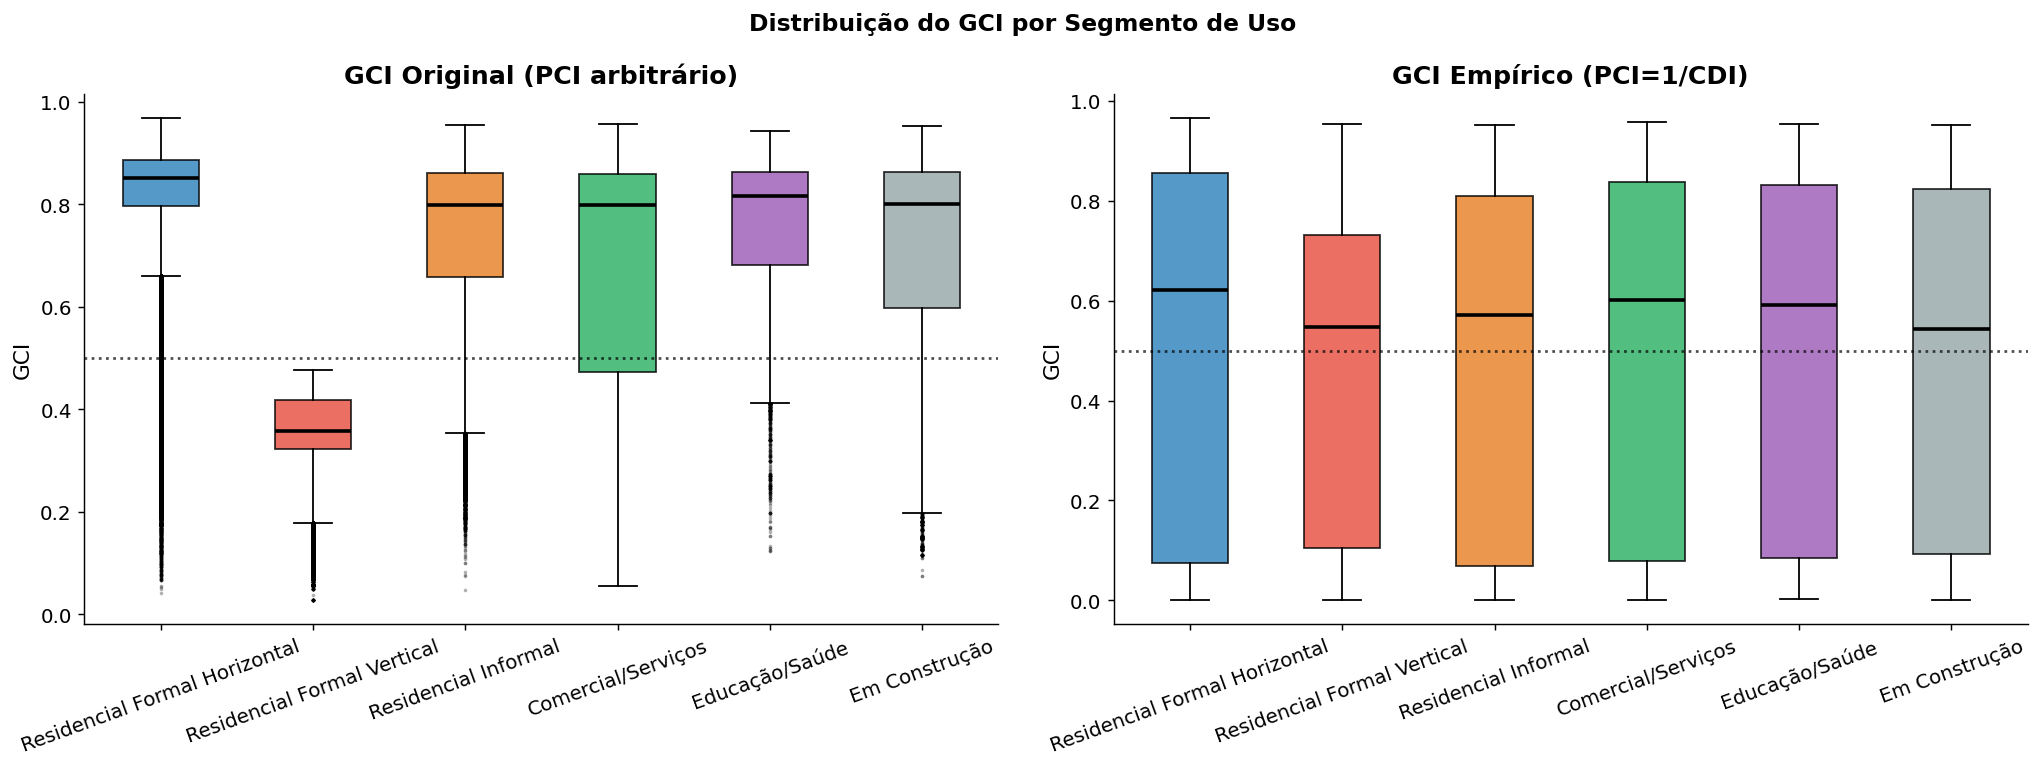

In [7]:
# Boxplot GCI por segmento (comparação visual)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (gci_col, titulo) in zip(axes, [
    ('GCI_original', 'GCI Original (PCI arbitrário)'),
    ('GCI_empirico', 'GCI Empírico (PCI=1/CDI)'),
]):
    if gci_col not in metrics.columns:
        continue
    data_segs = [metrics[metrics['segmento'] == s][gci_col].dropna().values for s in seg_present]
    bp = ax.boxplot(data_segs, labels=seg_present, patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 2},
                    flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3})
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.axhline(0.5, color='black', linestyle=':', linewidth=1.5, alpha=0.7)
    ax.set_ylabel('GCI')
    ax.set_title(titulo, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Distribuição do GCI por Segmento de Uso', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb10_seg_gci_boxplot.png', bbox_inches='tight')
plt.show()

O GCI_empírico do Formal Vertical deve ter mediana inferior ao do Informal Horizontal, confirmando o paradoxo H4 antes do teste formal.

KW significativo em todas as métricas (GCI, LCI, DRS, CCR), os seis segmentos não são amostras da mesma distribuição de qualidade. Com N=1,1M, isso é garantido para qualquer diferença real; o η² quantifica se a diferença tem magnitude operacional.

In [8]:
# Residencial informal vs formal: comparações par a par (Mann-Whitney U)
seg_col = metrics['segmento']
comparacoes = [
    ('Residencial Formal Horizontal', 'Residencial Informal'),
    ('Residencial Formal Horizontal', 'Residencial Formal Vertical'),
    ('Residencial Formal Vertical', 'Residencial Informal'),
]

print("Mann-Whitney U — Comparações par a par:")
print(f"{'Métrica':<18} {'Grupo A':<35} {'Grupo B':<35} {'p-value':>10} {'eff r':>8} {'media_A':>8} {'media_B':>8}")
print("-" * 125)

for col in ['GCI_original', 'GCI_empirico', 'LCI', 'match_distance']:
    if col not in metrics.columns:
        continue
    for a, b in comparacoes:
        result = mann_whitney_test(metrics, col, 'segmento', a, b)
        sig = '*' if result['p_value'] < 0.05 else ' '
        print(f"{col:<18} {a:<35} {b:<35} {result['p_value']:>10.2e}{sig} {result['effect_size_r']:>8.3f} {result['mean_a']:>8.3f} {result['mean_b']:>8.3f}")

Mann-Whitney U — Comparações par a par:
Métrica            Grupo A                             Grupo B                                p-value    eff r  media_A  media_B
-----------------------------------------------------------------------------------------------------------------------------


GCI_original       Residencial Formal Horizontal       Residencial Informal                  0.00e+00*   -0.308    0.811    0.747


GCI_original       Residencial Formal Horizontal       Residencial Formal Vertical           0.00e+00*   -0.956    0.811    0.356


GCI_original       Residencial Formal Vertical         Residencial Informal                  0.00e+00*    0.924    0.356    0.747


GCI_empirico       Residencial Formal Horizontal       Residencial Informal                  0.00e+00*   -0.099    0.498    0.462


...

LCI                Residencial Formal Horizontal       Residencial Formal Vertical           0.00e+00*   -0.405    0.994    0.909


LCI                Residencial Formal Vertical         Residencial Informal                  0.00e+00*    0.393    0.909    0.990


match_distance     Residencial Formal Horizontal       Residencial Informal                  0.00e+00*   -0.120    7.567    6.508


match_distance     Residencial Formal Horizontal       Residencial Formal Vertical           0.00e+00*    0.381    7.567   14.679


match_distance     Residencial Formal Vertical         Residencial Informal                  0.00e+00*   -0.458   14.679    6.508


## 4. Uso Funcional do Endereço: Residencial vs Comercial vs Institucional

*(Seção movida do NB09; as saídas refletem a execução original. O código abaixo opera sobre `metrics` = `cnefe_master_metrics.parquet` deste notebook.)*

Estabelecimentos institucionais (ensino, saúde) têm CDI=1 por definição, são pontos únicos, e portanto PCI_emp=1,0. Endereços comerciais podem ter menor precisão onde há numeração irregular ou lotes com uso heterogêneo.

,n,GCI_mediana,GCI_medio,LCI_medio,MCI_medio,erro_mediano,RMSE
uso_fn,,,,,,,
Comercial/Serviços,"125,070",0.602,0.492,0.993,0.801,6.8m,12.6m
Educação,"2,030",0.610,0.500,0.989,0.803,7.9m,15.0m
Em Construção,"18,722",0.544,0.480,0.991,0.769,7.0m,20.5m
Religioso,"3,788",0.602,0.489,0.997,0.804,6.5m,12.2m
Residencial,"1,020,779",0.575,0.480,0.961,0.805,6.4m,15.8m
Saúde,"2,480",0.569,0.482,0.986,0.793,7.8m,14.4m


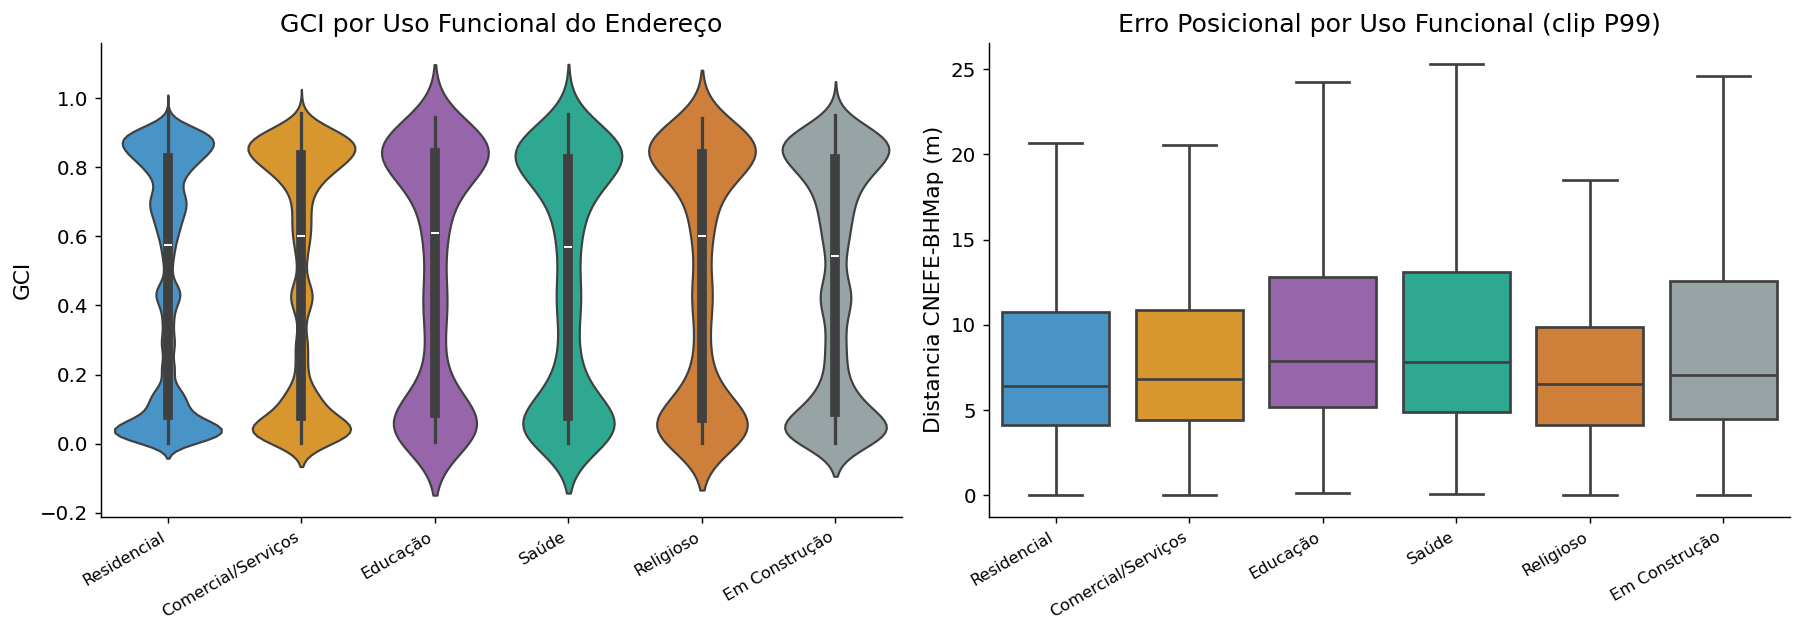


Kruskal-Wallis GCI:  H=170.7, p=5.21e-35
Kruskal-Wallis Erro: H=860.2, p=1.10e-183



Mann-Whitney Residencial vs Comercial/Servicos (GCI):
  r=0.0217, p=3.90e-36, GCI Resid=0.480, GCI Comerc=0.492


In [9]:
USO_MAP = {
    1: 'Residencial', 2: 'Residencial',
    3: 'Agropecuário',
    4: 'Educação', 5: 'Saúde', 8: 'Religioso',
    6: 'Comercial/Serviços',
    7: 'Em Construção',
}
uso_order = ['Residencial', 'Comercial/Serviços', 'Educação', 'Saúde', 'Religioso', 'Em Construção']
uso_colors = ['#3498db', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#95a5a6']
palette_uso = {u: c for u, c in zip(uso_order, uso_colors)}

gdf_uso_fn = metrics.copy()
gdf_uso_fn['uso_fn'] = gdf_uso_fn['COD_ESPECIE'].map(USO_MAP).fillna('Outros')
uso_present = [u for u in uso_order if u in gdf_uso_fn['uso_fn'].unique()]

# --- Tabela descritiva por uso funcional ---
tab_uso = gdf_uso_fn[gdf_uso_fn['uso_fn'].isin(uso_present)].groupby('uso_fn').agg(
    n=('GCI', 'count'),
    GCI_mediana=('GCI', 'median'),
    GCI_medio=('GCI', 'mean'),
    LCI_medio=('LCI', 'mean'),
    MCI_medio=('MCI', 'mean'),
    erro_mediano=('match_distance', 'median'),
    RMSE=('match_distance', lambda x: np.sqrt(np.mean(x.dropna()**2)))
).round(3)

display(tab_uso.style
    .background_gradient(subset=['GCI_mediana', 'GCI_medio', 'LCI_medio', 'MCI_medio'],
                          cmap='RdYlGn', vmin=0, vmax=1)
    .background_gradient(subset=['RMSE', 'erro_mediano'], cmap='OrRd')
    .format({'n': '{:,.0f}', 'GCI_mediana': '{:.3f}', 'GCI_medio': '{:.3f}',
             'LCI_medio': '{:.3f}', 'MCI_medio': '{:.3f}',
             'erro_mediano': '{:.1f}m', 'RMSE': '{:.1f}m'})
    .set_caption('Métricas de qualidade por uso funcional do endereço (COD_ESPECIE agrupado)'))

# --- Violin/boxplot estático: GCI e erro por uso funcional ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gdf_uso_fn_filt = gdf_uso_fn[gdf_uso_fn['uso_fn'].isin(uso_present)].copy()
sns.violinplot(data=gdf_uso_fn_filt, x='uso_fn', y='GCI', order=uso_present,
               palette=palette_uso, inner='box', ax=axes[0], linewidth=1.2)
axes[0].set_title('GCI por Uso Funcional do Endereço')
axes[0].set_xlabel('')
axes[0].set_ylabel('GCI')
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right', fontsize=9)

p99_uso = gdf_uso_fn_filt['match_distance'].quantile(0.99)
gdf_uso_fn_filt = gdf_uso_fn_filt.copy()
gdf_uso_fn_filt['dist_clip'] = gdf_uso_fn_filt['match_distance'].clip(0, p99_uso)
sns.boxplot(data=gdf_uso_fn_filt, x='uso_fn', y='dist_clip', order=uso_present,
            palette=palette_uso, ax=axes[1], showfliers=False, linewidth=1.5)
axes[1].set_title('Erro Posicional por Uso Funcional (clip P99)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Distancia CNEFE-BHMap (m)')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right', fontsize=9)

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb09_violin_uso_fn_gci.png', dpi=200, bbox_inches='tight')
plt.show()

# --- Kruskal-Wallis ---
kw_gci_uso = kruskal_wallis_test(gdf_uso_fn_filt, 'GCI', 'uso_fn')
kw_err_uso = kruskal_wallis_test(gdf_uso_fn_filt, 'match_distance', 'uso_fn')
print(f"\nKruskal-Wallis GCI:  H={kw_gci_uso['H']:.1f}, p={kw_gci_uso['p_value']:.2e}")
print(f"Kruskal-Wallis Erro: H={kw_err_uso['H']:.1f}, p={kw_err_uso['p_value']:.2e}")

mw_res_com = mann_whitney_test(gdf_uso_fn_filt, 'GCI', 'uso_fn', 'Residencial', 'Comercial/Serviços')
print(f"\nMann-Whitney Residencial vs Comercial/Servicos (GCI):")
print(f"  r={mw_res_com['effect_size_r']:.4f}, p={mw_res_com['p_value']:.2e}, "
      f"GCI Resid={mw_res_com['mean_a']:.3f}, GCI Comerc={mw_res_com['mean_b']:.3f}")


## 5. Distribuição Espacial dos Segmentos

A distribuição geográfica dos grupos deve estar alinhada com a segregação urbana conhecida de BH, precondição para que as diferenças de GCI observadas reflitam fenômenos urbanos reais e não artefatos de amostragem.

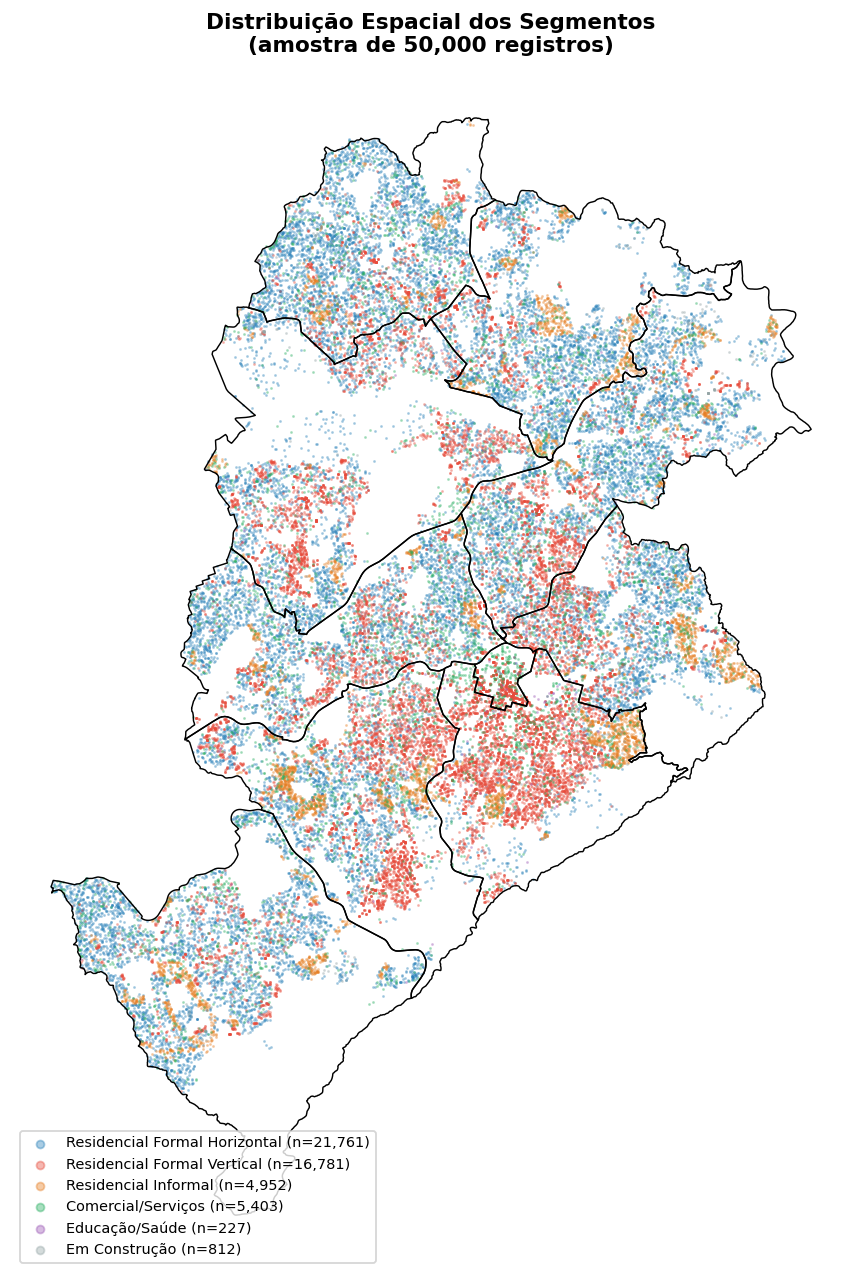

In [10]:
# Mapa: segmentação espacial dos registros
regionais = gpd.read_file(config.REGIONAIS_SHP).to_crs(config.TARGET_CRS)

# Amostra para visualização
sample_size = min(50000, len(metrics))
sample = metrics.sample(sample_size, random_state=42)

fig, ax = plt.subplots(figsize=(12, 10))
for seg, color in zip(SEG_ORDER, SEG_COLORS):
    sub = sample[sample['segmento'] == seg]
    if len(sub) > 0:
        sub.plot(ax=ax, color=color, markersize=0.3, alpha=0.4, label=f'{seg} (n={len(sub):,})')

regionais.boundary.plot(ax=ax, color='black', linewidth=0.8)
ax.set_title(f'Distribuição Espacial dos Segmentos\n(amostra de {sample_size:,} registros)',
             fontweight='bold', fontsize=12)
ax.legend(markerscale=8, fontsize=8, loc='lower left')
ax.axis('off')
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb10_seg_mapa.png', bbox_inches='tight', dpi=150)
plt.show()

A distribuição espacial confirma a segregação urbana de BH: Residencial Formal Vertical no Centro-Sul e Hipercentro; Residencial Informal nas bordas das regionais periféricas e em enclaves como o Aglomerado da Serra. O alinhamento entre distribuição dos segmentos e segregação conhecida valida que as diferenças de GCI observadas refletem fenômenos reais, não artefatos do pipeline.

---
## 6. Mapa Bivariado: Qualidade GCI × Informalidade por Setor

Cada setor recebe duas classificações simultâneas:
- **Eixo X**: % de área sobreposta com vilas/favelas
- **Eixo Y**: GCI mediano

A combinação 3×3 revela onde baixa qualidade e alta informalidade se concentram.

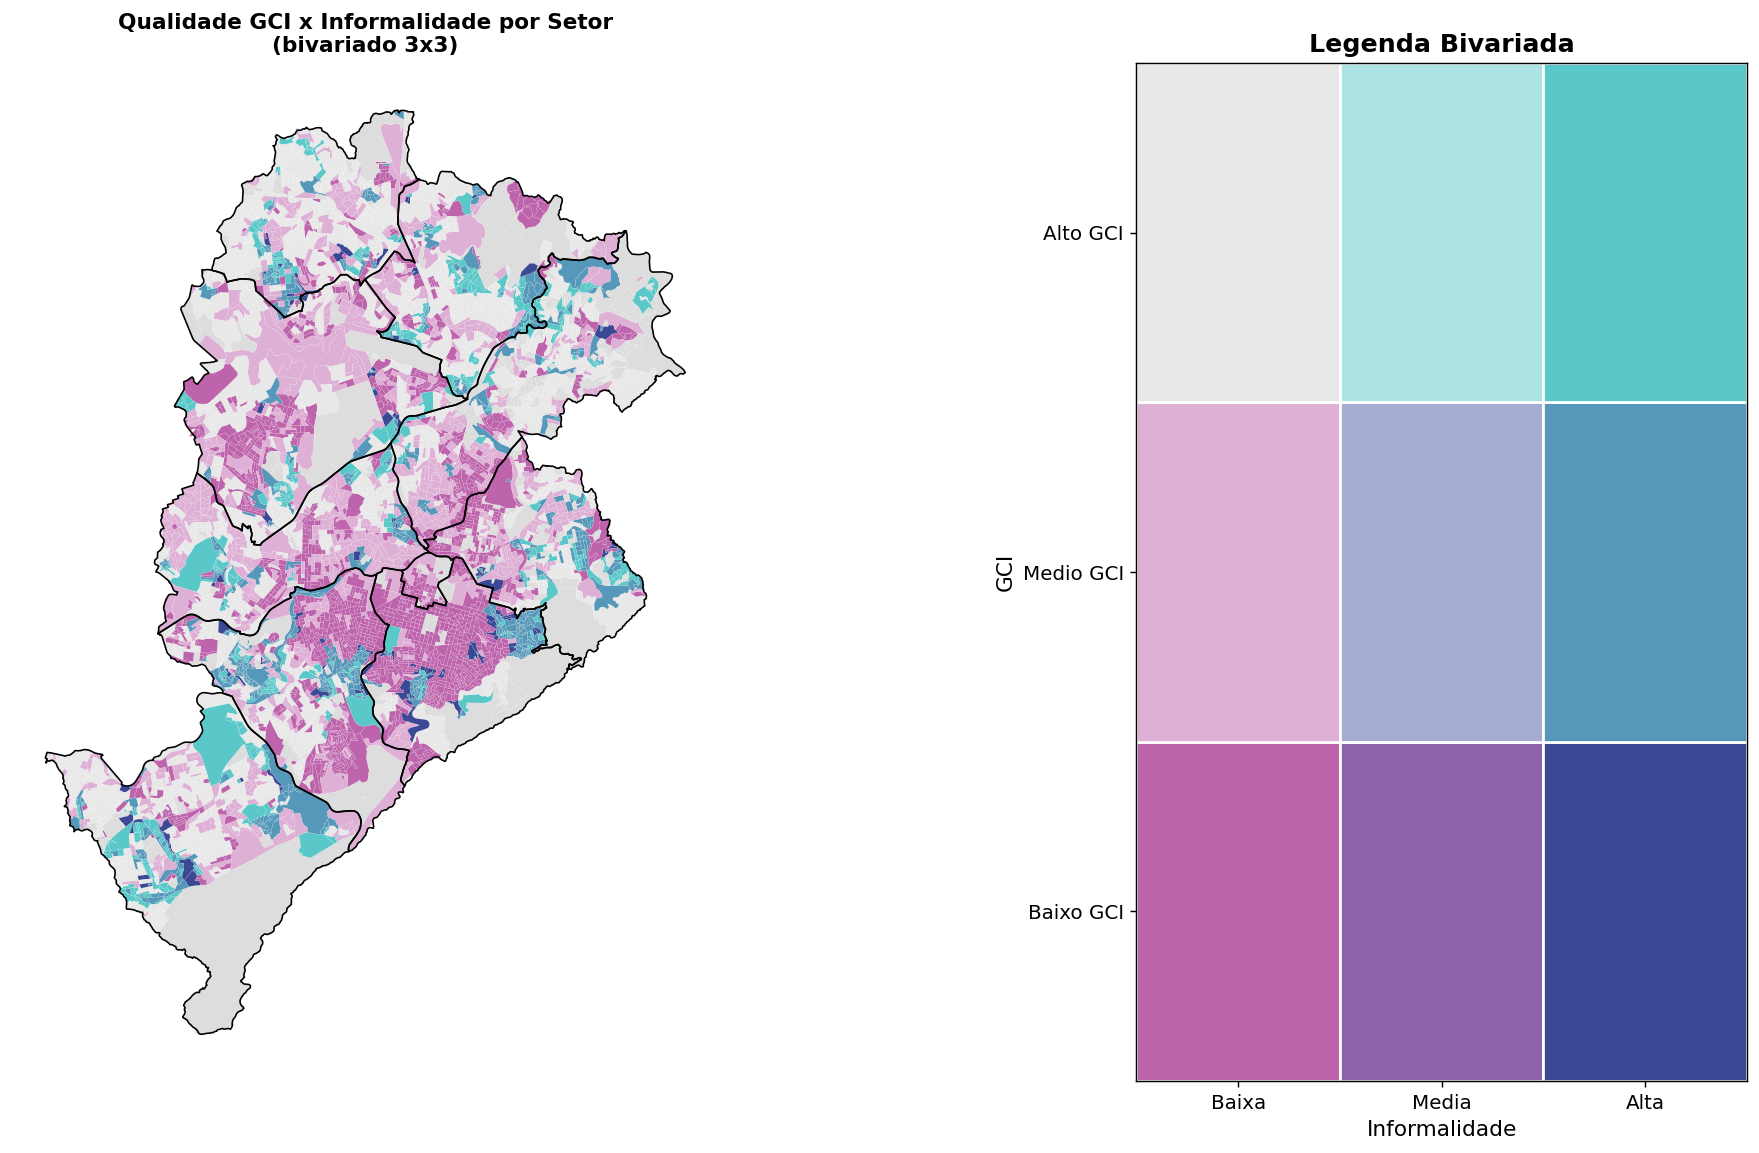

In [11]:
# Mapa bivariado: GCI x Informalidade por setor
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src import config

setores_biv = gpd.read_file(config.SETOR_CENSITARIO_SHP)
regionais_biv = gpd.read_file(config.REGIONAIS_SHP).to_crs(config.TARGET_CRS)
vilas_biv = gpd.read_file(config.VILAS_FAVELAS_SHP).to_crs(config.TARGET_CRS)

metrics_c = metrics.copy()
metrics_c['COD_SETOR_norm'] = metrics_c['COD_SETOR'].astype(str).str.rstrip('P').str.rstrip('S')
agg_biv = metrics_c.groupby('COD_SETOR_norm').agg(
    gci_orig=('GCI_original', 'median'), n=('GCI_original', 'count')
).reset_index()
gdf_biv = setores_biv.merge(agg_biv, left_on='COD_SETOR', right_on='COD_SETOR_norm', how='left')
gdf_biv = gdf_biv.to_crs(config.TARGET_CRS)

vilas_union = vilas_biv.geometry.unary_union
gdf_biv['area_total'] = gdf_biv.geometry.area
gdf_biv['area_vila'] = gdf_biv.geometry.apply(
    lambda g: g.intersection(vilas_union).area if g.is_valid else 0
)
gdf_biv['pct_informal'] = (gdf_biv['area_vila'] / gdf_biv['area_total'].clip(lower=1)).clip(0, 1)

gdf_v = gdf_biv.dropna(subset=['gci_orig', 'pct_informal'])
q_gci = pd.qcut(gdf_v['gci_orig'], 3, labels=['Baixo', 'Medio', 'Alto'], duplicates='drop')
inf_v = gdf_v['pct_informal']
p33, p67 = inf_v.quantile(1/3), inf_v.quantile(2/3)
lo = -1e-9; b1 = max(p33, lo+1e-9); b2 = max(p67, b1+1e-9); b3 = max(inf_v.max(), b2)+1e-9
q_inf = pd.cut(inf_v, bins=[lo, b1, b2, b3], labels=['Baixa', 'Media', 'Alta'], include_lowest=True)

bivar_colors = {
    ('Baixo','Baixa'):'#be64ac', ('Baixo','Media'):'#8c62aa', ('Baixo','Alta'):'#3b4994',
    ('Medio','Baixa'):'#dfb0d6', ('Medio','Media'):'#a5add3', ('Medio','Alta'):'#5698b9',
    ('Alto', 'Baixa'):'#e8e8e8', ('Alto', 'Media'):'#ace4e4', ('Alto', 'Alta'):'#5ac8c8',
}

def get_color(idx):
    gq = q_gci.loc[idx] if idx in q_gci.index else None
    iq = q_inf.loc[idx] if idx in q_inf.index else None
    if gq is None or iq is None or pd.isna(gq) or pd.isna(iq): return '#dddddd'
    return bivar_colors.get((str(gq), str(iq)), '#dddddd')

gdf_v = gdf_v.copy()
gdf_v['bivar_color'] = [get_color(i) for i in gdf_v.index]
gdf_biv['bivar_color'] = '#dddddd'
gdf_biv.loc[gdf_v.index, 'bivar_color'] = gdf_v['bivar_color']

fig, axes = plt.subplots(1, 2, figsize=(18, 9), gridspec_kw={'width_ratios': [3, 1]})
ax = axes[0]
gdf_biv.plot(color=gdf_biv['bivar_color'], ax=ax, linewidth=0.05, edgecolor='white')
regionais_biv.boundary.plot(ax=ax, color='black', linewidth=0.9)
ax.set_title('Qualidade GCI x Informalidade por Setor\n(bivariado 3x3)', fontweight='bold', fontsize=12)
ax.axis('off')
ax_leg = axes[1]
ax_leg.set_xlim(0, 3); ax_leg.set_ylim(0, 3)
for i, g in enumerate(['Baixo', 'Medio', 'Alto']):
    for j, inf in enumerate(['Baixa', 'Media', 'Alta']):
        rect = plt.Rectangle((j, i), 1, 1, facecolor=bivar_colors.get((g,inf),'#ddd'),
                             edgecolor='white', linewidth=1.5)
        ax_leg.add_patch(rect)
ax_leg.set_xticks([0.5,1.5,2.5]); ax_leg.set_xticklabels(['Baixa','Media','Alta'])
ax_leg.set_yticks([0.5,1.5,2.5]); ax_leg.set_yticklabels(['Baixo GCI','Medio GCI','Alto GCI'])
ax_leg.set_xlabel('Informalidade'); ax_leg.set_ylabel('GCI')
ax_leg.set_title('Legenda Bivariada', fontweight='bold')
ax_leg.spines[:].set_visible(True)
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb10_seg_bivariado_gci_informalidade.png', bbox_inches='tight', dpi=150)
plt.show()

A matriz 3×3 revela o cruzamento espacial entre qualidade de geocodificação e intensidade de informalidade: a célula crítica (Baixo GCI + Alta informalidade) concentra setores do Aglomerado da Serra, IAPI e Norte. O padrão confirma que informalidade e baixa qualidade co-localizam, mas a direção causal é mediada pelo CDI, não pelo tipo de assentamento per se.

---
## 7. Desigualdade Intra-segmento: Curvas de Lorenz e Gini

As curvas de Lorenz mostram a **distribuição interna do GCI** em cada segmento.
Um Gini alto indica muita heterogeneidade dentro do segmento, 
alguns endereços bem geocodificados e outros muito mal.

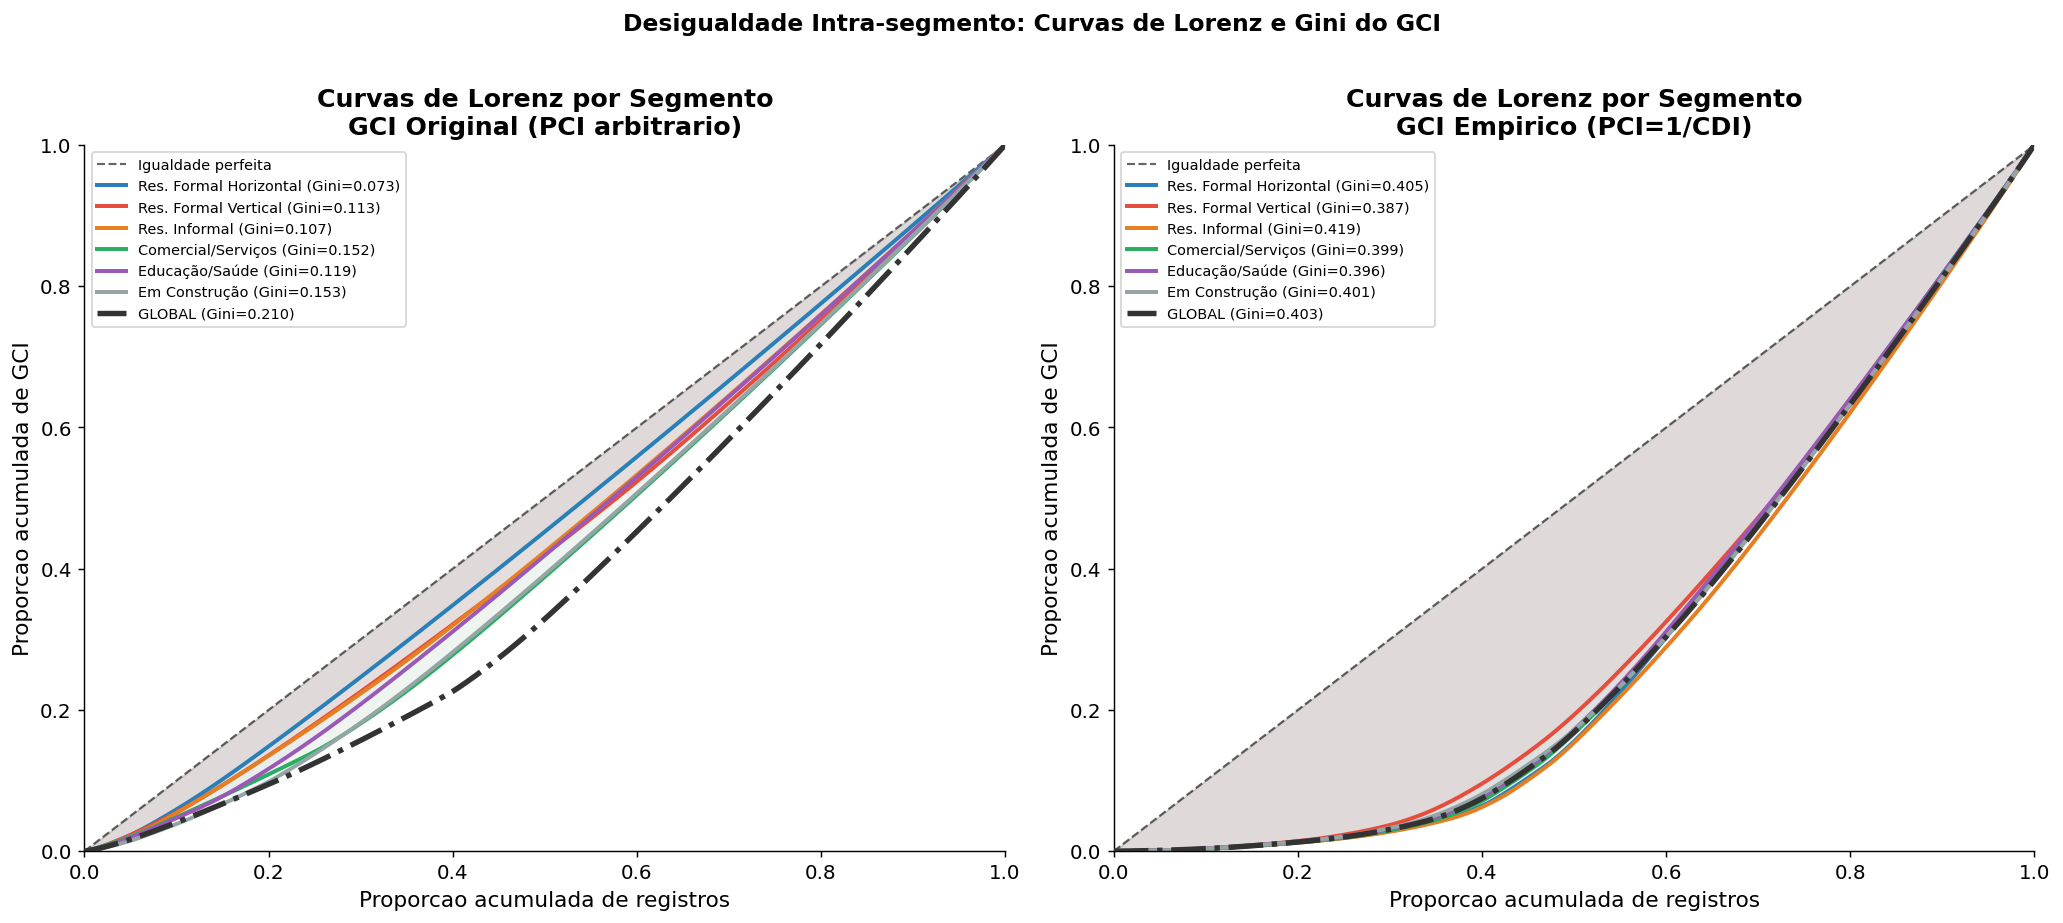

In [12]:
# Curvas de Lorenz do GCI por segmento (desigualdade intra-segmento)
import numpy as np

# np.trapz removed in NumPy 2.0; use conditional to avoid eager evaluation of np.trapz
_trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

def lorenz_curve(values):
    vals = np.sort(values[~np.isnan(values)])
    if len(vals) == 0 or vals.sum() == 0:
        return np.array([0, 1]), np.array([0, 1]), 0
    cum_share = np.cumsum(vals) / vals.sum()
    x = np.linspace(0, 1, len(vals))
    gini = 1 - 2 * _trapz(cum_share, x)
    return x, cum_share, gini

seg_present = [s for s in SEG_ORDER if s in metrics['segmento'].unique()]
colors_plot = [SEG_COLORS[SEG_ORDER.index(s)] for s in seg_present]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (gci_col, titulo) in zip(axes, [
    ('GCI_original', 'GCI Original (PCI arbitrario)'),
    ('GCI_empirico', 'GCI Empirico (PCI=1/CDI)'),
]):
    ax.plot([0,1], [0,1], 'k--', linewidth=1.2, label='Igualdade perfeita', alpha=0.6)
    for seg, color in zip(seg_present, colors_plot):
        vals = metrics[metrics['segmento'] == seg][gci_col].dropna().values
        if len(vals) < 10: continue
        x, y, gini = lorenz_curve(vals)
        ax.plot(x, y, color=color, linewidth=2.2,
                label=f'{seg.replace("Residencial ","Res. ")} (Gini={gini:.3f})')
        ax.fill_between(x, x, y, alpha=0.05, color=color)
    vals_all = metrics[gci_col].dropna().values
    x, y, gini_all = lorenz_curve(vals_all)
    ax.plot(x, y, color='#333333', linewidth=3.0, linestyle='dashdot',
            label=f'GLOBAL (Gini={gini_all:.3f})', zorder=5)
    ax.set_xlabel('Proporcao acumulada de registros')
    ax.set_ylabel('Proporcao acumulada de GCI')
    ax.set_title(f'Curvas de Lorenz por Segmento\n{titulo}', fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.suptitle('Desigualdade Intra-segmento: Curvas de Lorenz e Gini do GCI',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb10_seg_lorenz.png', bbox_inches='tight')
plt.show()

O Gini intra-segmento mede heterogeneidade interna: Residencial Informal tende a Gini mais elevado, mesmo dentro das vilas, há endereços bem geocodificados (casas horizontais com GPS de campo) e endereços problemáticos (estimados ou com CDI > 1 em edifícios de múltiplos andares em assentamentos mais adensados).

### Síntese parcial: segmentação por uso e assentamento

A segmentação por uso e assentamento confirma que informalidade e verticalização são os dois eixos que mais penalizam o GCI_empírico. O mapa bivariado GCI×informalidade e as curvas de Lorenz documentam a desigualdade espacial da qualidade. O Notebook 11 quantifica a estrutura espacial dessa desigualdade via autocorrelação e clustering.

---
## 8. Risco Ambiental e Vulnerabilidade Composta

As análises 8.1 a 8.5 utilizam `cnefe_master_metrics.parquet` para incorporar dimensões de vulnerabilidade urbana estrutural ao GCI_empírico:

| # | Análise | Variáveis |
|---|---------|----------|
| 8.1 | GCI por exposição a risco ambiental | `em_risco` (inundação / escorregamento) |
| 8.2 | Vulnerabilidade composta (double jeopardy) | `IVS_ALTO` (IVS>=3) AND `em_risco` |
| 8.3 | Estabelecimentos não-residenciais × GCI | `FLAG_ESTAB_VALIDADO`, `DENS_ATIV_ECON_KM2` |
| 8.4 | Informalidade urbana × GCI | `TIPO_ASSENTAMENTO`, `TEM_PLANO_URBANO` |
| 8.5 | Idade do imóvel e infraestrutura × GCI | `IDADE_IMOVEL`, `IND_GALERIA_PLUVIAL` |

**Justificativa teórica**: em contextos urbanos de países em desenvolvimento, a qualidade de dados geográficos sofre penalização dupla em áreas de risco: o recenseador enfrenta barreiras de acesso e o endereçamento é irregular ou ausente. Documentar esse efeito é uma contribuição empírica direta da dissertação.

> **Pré-requisito**: execute `python run_pipeline.py --from etl` para gerar `cnefe_master_metrics.parquet`.

### 8.1 GCI por Exposição a Risco Ambiental

Compara o GCI_empírico entre registros dentro e fora de polígonos de risco (AREA_RISCO BHMap: inundação e escorregamento), via Mann-Whitney.

v3 carregado: 1,172,902 registros x 116 colunas
Pontos em area de risco: 91,483 (7.8%)


Tipos de risco:
TIPO_RISCO
ESCORREGAMENTO    72638
INUNDACAO         18845


,n,GCI_mediana,GCI_medio,LCI_medio,MCI_medio,erro_mediano
RISCO_LABEL,,,,,,
Em Area de Risco,"91,483",0.561,0.474,0.964,0.778,7.2m
Sem Risco Ambiental,"1,081,419",0.579,0.482,0.965,0.806,6.4m


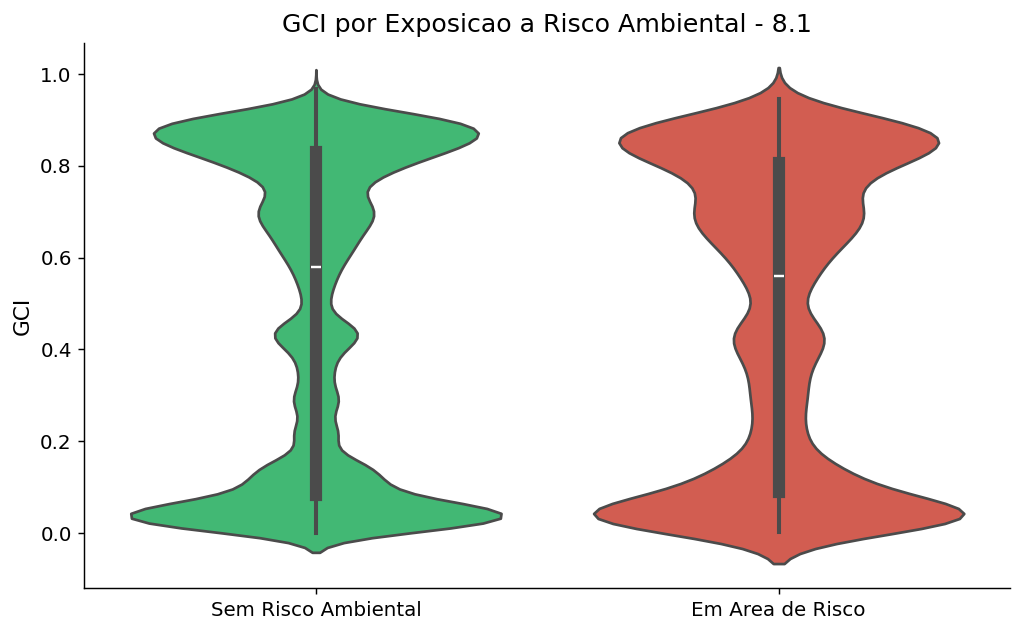


Mann-Whitney 8.1 (Sem Risco vs Em Risco):
  r=-0.0308, p=5.25e-54
  GCI Sem Risco=0.482, GCI Em Risco=0.474


In [13]:
# 8.1 — em_risco vs GCI: qualidade por exposicao a risco ambiental (BHMap AREA_RISCO)

v3_path_c = config.PROCESSED_DIR / 'cnefe_master_metrics.parquet'
if not v3_path_c.exists():
    print("cnefe_master_metrics.parquet nao encontrado.")
    print("Execute: python run_pipeline.py --from etl")
    metricas_v3 = None
else:
    import geopandas as gpd
    metricas_v3 = gpd.read_parquet(v3_path_c)
    print(f"v3 carregado: {len(metricas_v3):,} registros x {metricas_v3.shape[1]} colunas")

    risco_col = 'em_risco'
    if risco_col not in metricas_v3.columns:
        print(f"Coluna {risco_col} nao encontrada em v3.")
    else:
        n_risco = metricas_v3[risco_col].sum()
        print(f"Pontos em area de risco: {n_risco:,} ({n_risco/len(metricas_v3)*100:.1f}%)")

        metricas_v3['RISCO_LABEL'] = np.where(
            metricas_v3[risco_col] == 1, 'Em Area de Risco', 'Sem Risco Ambiental'
        )
        tipo_risco_counts = metricas_v3.loc[metricas_v3[risco_col]==1, 'TIPO_RISCO'].value_counts() \
            if 'TIPO_RISCO' in metricas_v3.columns else None
        if tipo_risco_counts is not None:
            print("Tipos de risco:")
            print(tipo_risco_counts.to_string())

        gci_col_c = 'GCI' if 'GCI' in metricas_v3.columns else 'GCI_empirico'
        tab_risco = metricas_v3.groupby('RISCO_LABEL').agg(
            n=(gci_col_c, 'count'),
            GCI_mediana=(gci_col_c, 'median'),
            GCI_medio=(gci_col_c, 'mean'),
            LCI_medio=('LCI', 'mean'),
            MCI_medio=('MCI', 'mean'),
            erro_mediano=('match_distance', 'median'),
        ).round(3)
        display(tab_risco.style
            .background_gradient(subset=['GCI_mediana', 'GCI_medio'], cmap='RdYlGn', vmin=0, vmax=1)
            .background_gradient(subset=['erro_mediano'], cmap='OrRd')
            .format({'n': '{:,.0f}', 'GCI_mediana': '{:.3f}', 'GCI_medio': '{:.3f}',
                     'LCI_medio': '{:.3f}', 'MCI_medio': '{:.3f}', 'erro_mediano': '{:.1f}m'})
            .set_caption('GCI por Exposicao a Risco Ambiental (AREA_RISCO BHMap) — 8.1'))

        # --- Violin plot estático: GCI por exposição a risco ---
        fig_risco, ax_risco = plt.subplots(figsize=(8, 5))
        sns.violinplot(data=metricas_v3, x='RISCO_LABEL', y=gci_col_c,
                      palette={'Em Area de Risco': '#e74c3c',
                               'Sem Risco Ambiental': '#2ecc71'},
                      inner='box', ax=ax_risco, linewidth=1.5)
        ax_risco.set_title('GCI por Exposicao a Risco Ambiental - 8.1')
        ax_risco.set_xlabel('')
        ax_risco.set_ylabel('GCI')
        plt.tight_layout()
        plt.savefig(config.FIG_DIR / 'nb10_risco_gci.png', dpi=180, bbox_inches='tight')
        plt.show()

        mw = mann_whitney_test(metricas_v3, gci_col_c, 'RISCO_LABEL',
                               'Sem Risco Ambiental', 'Em Area de Risco')
        print(f"\nMann-Whitney 8.1 (Sem Risco vs Em Risco):")
        print(f"  r={mw['effect_size_r']:.4f}, p={mw['p_value']:.2e}")
        print(f"  GCI Sem Risco={mw['mean_a']:.3f}, GCI Em Risco={mw['mean_b']:.3f}")

### 8.2 Vulnerabilidade Composta: IVS Alto + Área de Risco (Double Jeopardy)

**Hipótese**: Endereços em setores de alta vulnerabilidade social (`IVS_SCORE >= 3`) **e** em áreas de risco ambiental (`em_risco=1`) sofrem dupla penalização: menor qualidade de geocodificação por mecanismos independentes: (a) o IBGE usa estimação em áreas de difícil acesso, reduzindo LCI; (b) a irregularidade do endereçamento em assentamentos de risco reduz MCI.

**Variáveis**: `IVS_ALTO` = IVS_SCORE >= 3; `em_risco` = ponto dentro de polígono AREA_RISCO. `VULNERAB_COMPOSTA` = IVS_ALTO AND em_risco. Análise 2×2 compara os 4 grupos.

,n,GCI_mediana,GCI_medio,LCI_medio,erro_mediano
VULN_GROUP,,,,,
Alto IVS + Com Risco (double jeopardy),"39,501",0.554,0.468,0.988,5.8m
Alto IVS + Sem Risco,"228,819",0.562,0.476,0.986,5.7m
Baixo IVS + Com Risco,"51,982",0.567,0.479,0.947,8.6m
Baixo IVS + Sem Risco,"852,600",0.584,0.484,0.959,6.6m


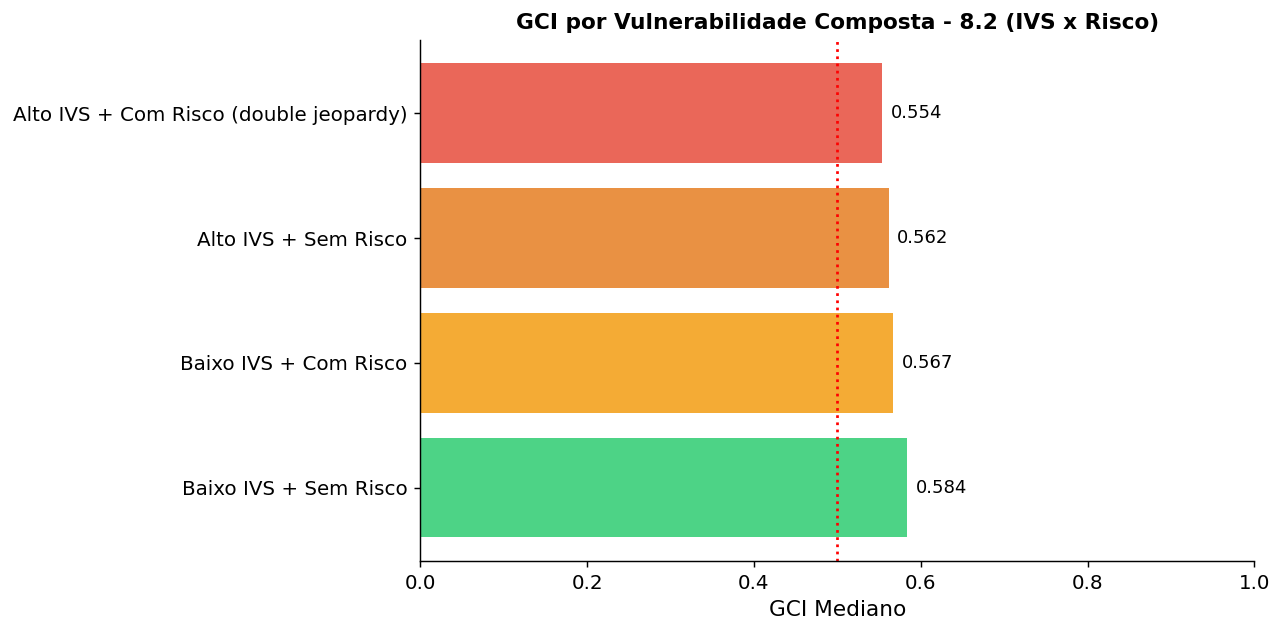

Double jeopardy (IVS_ALTO + em_risco): 39,501 (3.4%)


Kruskal-Wallis 8.2 (VULN_GROUP -> GCI): H=313.3, p=1.34e-67


Mann-Whitney referencia vs double jeopardy: r=-0.0432, p=6.23e-48
  GCI referencia=0.484, GCI double jeopardy=0.468


In [14]:
# 8.2 — Vulnerabilidade Composta (IVS_ALTO x em_risco): double jeopardy analysis
from IPython.display import Image as IPImage, display
import matplotlib.pyplot as plt

if 'metricas_v3' not in dir() or metricas_v3 is None:
    import geopandas as gpd
    metricas_v3 = gpd.read_parquet(config.PROCESSED_DIR / 'cnefe_master_metrics.parquet')

vuln_col = 'VULNERAB_COMPOSTA'
ivs_col  = 'IVS_SCORE'
risco_col_c = 'em_risco'

if not all(c in metricas_v3.columns for c in [ivs_col, risco_col_c]):
    print("Colunas IVS_SCORE ou em_risco nao disponiveis em v3.")
else:
    if 'IVS_ALTO' not in metricas_v3.columns:
        metricas_v3['IVS_ALTO'] = (metricas_v3[ivs_col] >= 3).fillna(0).astype(int)
    if vuln_col not in metricas_v3.columns:
        metricas_v3[vuln_col] = ((metricas_v3['IVS_ALTO'] == 1) &
                                  (metricas_v3[risco_col_c] == 1)).astype(int)

    grp_labels = {
        (0, 0): 'Baixo IVS + Sem Risco',
        (0, 1): 'Baixo IVS + Com Risco',
        (1, 0): 'Alto IVS + Sem Risco',
        (1, 1): 'Alto IVS + Com Risco (double jeopardy)',
    }
    metricas_v3['VULN_GROUP'] = [
        grp_labels.get((int(row.IVS_ALTO), int(getattr(row, risco_col_c))), 'N/D')
        for row in metricas_v3[['IVS_ALTO', risco_col_c]].itertuples()
    ]
    grp_order = list(grp_labels.values())
    grp_present = [g for g in grp_order if g in metricas_v3['VULN_GROUP'].unique()]
    mv3_grp = metricas_v3[metricas_v3['VULN_GROUP'].isin(grp_present)].copy()

    gci_col_v = 'GCI' if 'GCI' in mv3_grp.columns else 'GCI_empirico'
    tab_vuln = mv3_grp.groupby('VULN_GROUP', observed=True).agg(
        n=(gci_col_v, 'count'),
        GCI_mediana=(gci_col_v, 'median'),
        GCI_medio=(gci_col_v, 'mean'),
        LCI_medio=('LCI', 'mean'),
        erro_mediano=('match_distance', 'median'),
    ).round(3)
    display(tab_vuln.style
        .background_gradient(subset=['GCI_mediana', 'GCI_medio'], cmap='RdYlGn', vmin=0, vmax=1)
        .background_gradient(subset=['erro_mediano'], cmap='OrRd')
        .format({'n': '{:,.0f}', 'GCI_mediana': '{:.3f}', 'GCI_medio': '{:.3f}',
                 'LCI_medio': '{:.3f}', 'erro_mediano': '{:.1f}m'})
        .set_caption('GCI por Grupo de Vulnerabilidade Composta (2x2: IVS_ALTO x em_risco)'))

    colors_vuln = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
    tab_v_idx = [g for g in grp_present if g in tab_vuln.index]
    fig_vuln, ax_vuln = plt.subplots(figsize=(10, 5))
    c_map = {g: colors_vuln[grp_order.index(g)] for g in grp_order}
    bars = ax_vuln.barh(tab_v_idx, tab_vuln.loc[tab_v_idx, 'GCI_mediana'],
                        color=[c_map[g] for g in tab_v_idx], alpha=0.85)
    ax_vuln.set_xlim(0, 1)
    ax_vuln.axvline(0.5, color='red', linestyle=':', linewidth=1.5)
    ax_vuln.set_xlabel('GCI Mediano')
    ax_vuln.set_title('GCI por Vulnerabilidade Composta - 8.2 (IVS x Risco)',
                      fontweight='bold', fontsize=12)
    for bar, val in zip(bars, tab_vuln.loc[tab_v_idx, 'GCI_mediana']):
        ax_vuln.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                     f'{val:.3f}', va='center', fontsize=10)
    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb10_vulnerabilidade_composta.png', dpi=150, bbox_inches='tight')
    plt.show()

    n_double = metricas_v3[vuln_col].sum()
    print(f"Double jeopardy (IVS_ALTO + em_risco): {n_double:,} ({n_double/len(metricas_v3)*100:.1f}%)")
    kw_vuln = kruskal_wallis_test(mv3_grp, gci_col_v, 'VULN_GROUP')
    print(f"Kruskal-Wallis 8.2 (VULN_GROUP -> GCI): H={kw_vuln['H']:.1f}, p={kw_vuln['p_value']:.2e}")
    mw_dj = mann_whitney_test(mv3_grp, gci_col_v, 'VULN_GROUP',
                               'Baixo IVS + Sem Risco', 'Alto IVS + Com Risco (double jeopardy)')
    print(f"Mann-Whitney referencia vs double jeopardy: r={mw_dj['effect_size_r']:.4f}, p={mw_dj['p_value']:.2e}")
    print(f"  GCI referencia={mw_dj['mean_a']:.3f}, GCI double jeopardy={mw_dj['mean_b']:.3f}")

### 8.3 Cobertura Comercial e Estabelecimentos (COD_ESPECIE 6/7) × GCI_empírico

**Pergunta**: o CNEFE cobre endereços comerciais, e a qualidade deles difere da dos domicílios? Os estabelecimentos não residenciais (`COD_ESPECIE` = 6, outras finalidades, e 7, em construção) são o proxy de comércio, já que o CNEFE não rotula o comércio isoladamente.

Utiliza `FLAG_ESTABELECIMENTO`, `FLAG_ESTAB_VALIDADO` e `DIST_ATIV_MIN_M` de `cnefe_master_metrics.parquet`. A densidade de atividade econômica (`DENS_ATIV_ECON_KM2`) está indisponível no ETL atual.

v3 carregado: 1,172,902 registros



Perfil GCI_empírico por Espécie:


,N,Mediana,Media,DP,Q1,Q3
especie_label,,,,,,
Domicílio Coletivo,"1,346",0.5579,0.4769,0.3280,0.1078,0.8081
Domicílio Particular,"1,019,433",0.5749,0.4805,0.3452,0.0843,0.8272
Em Construção,"18,722",0.5435,0.4799,0.3415,0.0918,0.8234
Estab. Agropecuário,33,0.6185,0.5214,0.3038,0.2136,0.7663
Estab. Ensino,"2,030",0.6103,0.5004,0.3499,0.0890,0.8402
Estab. Religioso,"3,788",0.6025,0.4890,0.3567,0.0742,0.8393
Estab. Saúde,"2,480",0.5691,0.4820,0.3466,0.0808,0.8247
Outras Finalidades,"125,070",0.6015,0.4916,0.3534,0.0797,0.8370



Mann-Whitney (Estabelecimento vs Domicílio):
  p=9.78e-30, r=-0.0184
  GCI mediano Estab.:   0.5940 (N=143,792)
  GCI mediano Domicílio: 0.5750 (N=1,029,110)



Mann-Whitney (Estab. Validado vs Não-Validado) [entre estabelecimentos]:
  p=5.59e-20, r=-0.1266
  GCI mediano Validado:   0.5991 (N=142,029)
  GCI mediano Não-Validado: 0.4188 (N=1,763)


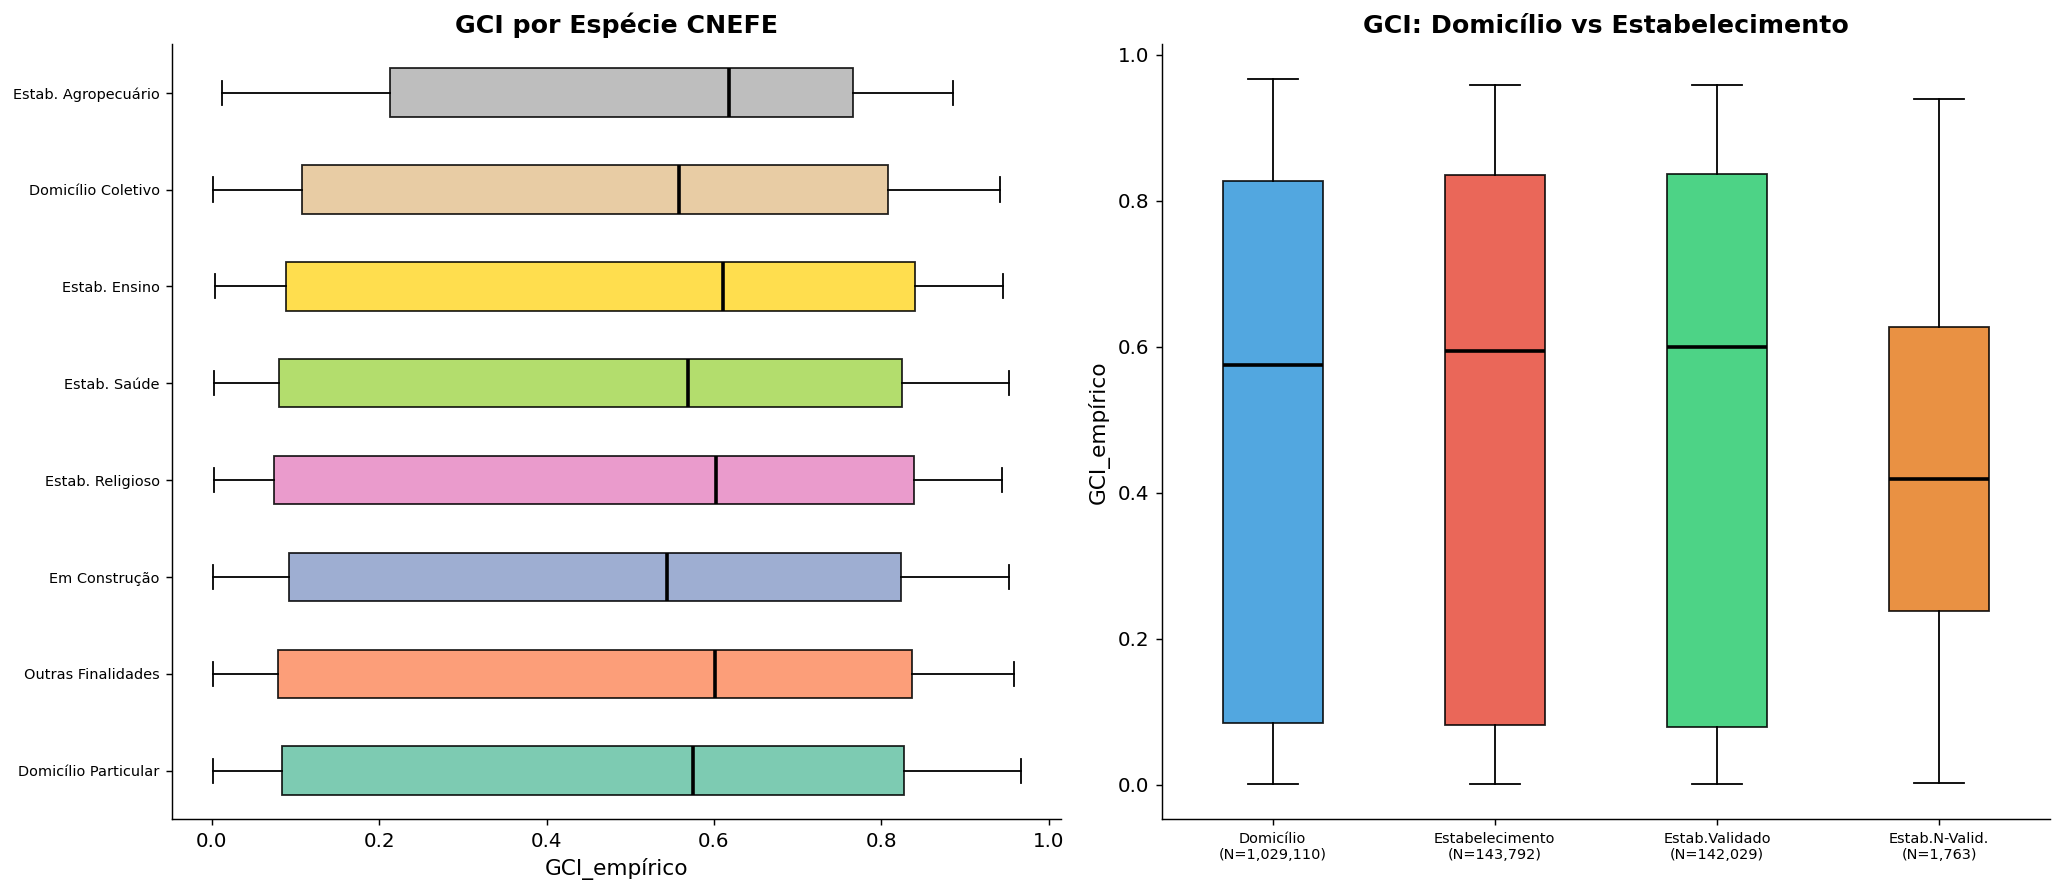


Cobertura comercial (proxy = especie 6, 'outras finalidades'):
  Registros comerciais: 125,070 (10.7% do CNEFE)
  GCI mediano comercial: 0.602 vs domicilio 0.575
  Estabelecimentos validados (FLAG_ESTAB_VALIDADO): 142,029
  Spearman (dist. a ativ. economica x GCI): r=-0.0580, p=4.33e-106, N=142,029


In [15]:
# 8.3 – Cobertura comercial e estabelecimentos (COD_ESPECIE, FLAG_ESTAB_VALIDADO) × GCI_empírico
from scipy import stats

GCI_COL = 'GCI_empirico'

try:
    v3_path = config.PROCESSED_DIR / 'cnefe_master_metrics.parquet'
    if 'gdf_v3' not in dir() or gdf_v3 is None:
        import geopandas as gpd
        gdf_v3 = gpd.read_parquet(v3_path)
        print(f"v3 carregado: {len(gdf_v3):,} registros")

    cols_need = ['FLAG_ESTABELECIMENTO', GCI_COL]
    if 'especie_label' not in gdf_v3.columns:
        gdf_v3['especie_label'] = gdf_v3['COD_ESPECIE'].map(config.ESPECIE_MAP).fillna('Desconhecido')
    if not all(c in gdf_v3.columns for c in cols_need):
        print("Colunas de estabelecimento ausentes — execute run_pipeline.py --from etl")
    else:
        esp_profile = gdf_v3.groupby('especie_label')[GCI_COL].agg(
            N='count', Mediana='median', Media='mean', DP='std',
            Q1=lambda x: x.quantile(0.25), Q3=lambda x: x.quantile(0.75)
        ).round(4)
        print("\nPerfil GCI_empírico por Espécie:")
        display(esp_profile.style
            .background_gradient(subset=['Mediana'], cmap='RdYlGn', vmin=0, vmax=1)
            .format({'N': '{:,.0f}', 'Mediana': '{:.4f}', 'Media': '{:.4f}',
                     'DP': '{:.4f}', 'Q1': '{:.4f}', 'Q3': '{:.4f}'})
            .set_caption('GCI_empírico por Espécie CNEFE'))

        g_estab = gdf_v3[gdf_v3['FLAG_ESTABELECIMENTO'] == True][GCI_COL].dropna()
        g_dom   = gdf_v3[gdf_v3['FLAG_ESTABELECIMENTO'] == False][GCI_COL].dropna()
        p_mw, r_mw = np.nan, np.nan
        if len(g_estab) >= 30 and len(g_dom) >= 30:
            U, p_mw = stats.mannwhitneyu(g_estab, g_dom, alternative='two-sided')
            r_mw = 1 - 2*U / (len(g_estab) * len(g_dom))
            print(f"\nMann-Whitney (Estabelecimento vs Domicílio):")
            print(f"  p={p_mw:.2e}, r={r_mw:.4f}")
            print(f"  GCI mediano Estab.:   {g_estab.median():.4f} (N={len(g_estab):,})")
            print(f"  GCI mediano Domicílio: {g_dom.median():.4f} (N={len(g_dom):,})")

        p_mw_val, r_mw_val = np.nan, np.nan
        g_val, g_nval = np.array([]), np.array([])
        if 'FLAG_ESTAB_VALIDADO' in gdf_v3.columns:
            sub_estab = gdf_v3[gdf_v3['FLAG_ESTABELECIMENTO'] == True].dropna(
                subset=['FLAG_ESTAB_VALIDADO', GCI_COL])
            g_val  = sub_estab[sub_estab['FLAG_ESTAB_VALIDADO'] == True][GCI_COL].values
            g_nval = sub_estab[sub_estab['FLAG_ESTAB_VALIDADO'] == False][GCI_COL].values
            if len(g_val) >= 30 and len(g_nval) >= 30:
                U2, p_mw_val = stats.mannwhitneyu(g_val, g_nval, alternative='two-sided')
                r_mw_val = 1 - 2*U2 / (len(g_val) * len(g_nval))
                print(f"\nMann-Whitney (Estab. Validado vs Não-Validado) [entre estabelecimentos]:")
                print(f"  p={p_mw_val:.2e}, r={r_mw_val:.4f}")
                print(f"  GCI mediano Validado:   {np.median(g_val):.4f} (N={len(g_val):,})")
                print(f"  GCI mediano Não-Validado: {np.median(g_nval):.4f} (N={len(g_nval):,})")

        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        ax = axes[0]
        top_esp = esp_profile.nlargest(8, 'N').index.tolist()
        data_esp = [gdf_v3[gdf_v3['especie_label'] == e][GCI_COL].dropna().values for e in top_esp]
        bp = ax.boxplot(data_esp, vert=False, patch_artist=True,
                        medianprops={'color': 'black', 'linewidth': 2},
                        flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3})
        colors_esp = plt.cm.Set2(np.linspace(0, 1, len(top_esp)))
        for patch, color in zip(bp['boxes'], colors_esp):
            patch.set_facecolor(color); patch.set_alpha(0.85)
        ax.set_yticks(range(1, len(top_esp) + 1))
        ax.set_yticklabels(top_esp, fontsize=8)
        ax.set_xlabel('GCI_empírico')
        ax.set_title('GCI por Espécie CNEFE', fontweight='bold')

        ax = axes[1]
        data_groups, labels_g, colors_g = [], [], []
        data_groups.append(g_dom.values); labels_g.append(f'Domicílio\n(N={len(g_dom):,})')
        colors_g.append('#3498db')
        data_groups.append(g_estab.values); labels_g.append(f'Estabelecimento\n(N={len(g_estab):,})')
        colors_g.append('#e74c3c')
        if len(g_val) >= 30:
            data_groups.append(g_val); labels_g.append(f'Estab.Validado\n(N={len(g_val):,})')
            colors_g.append('#2ecc71')
            data_groups.append(g_nval); labels_g.append(f'Estab.N-Valid.\n(N={len(g_nval):,})')
            colors_g.append('#e67e22')
        bp2 = ax.boxplot(data_groups, patch_artist=True,
                         medianprops={'color': 'black', 'linewidth': 2},
                         flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3})
        for patch, color in zip(bp2['boxes'], colors_g):
            patch.set_facecolor(color); patch.set_alpha(0.85)
        ax.set_xticks(range(1, len(labels_g) + 1))
        ax.set_xticklabels(labels_g, fontsize=8)
        ax.set_ylabel('GCI_empírico')
        ax.set_title('GCI: Domicílio vs Estabelecimento', fontweight='bold')
        plt.tight_layout()
        plt.savefig(config.FIG_DIR / 'nb10_estabelecimentos_gci.png', bbox_inches='tight', dpi=130)
        plt.show()

        # Cobertura comercial: o CNEFE cobre enderecos comerciais?
        # DENS_ATIV_ECON_KM2 esta indisponivel (coluna nula no ETL); usa-se COD_ESPECIE
        # (especie 6 = "outras finalidades", proxy do comercio) e DIST_ATIV_MIN_M.
        n_total = len(gdf_v3)
        n_com = int((gdf_v3['COD_ESPECIE'] == 6).sum())
        gci_com = gdf_v3.loc[gdf_v3['COD_ESPECIE'] == 6, GCI_COL].median()
        gci_dom = gdf_v3.loc[gdf_v3['COD_ESPECIE'] == 1, GCI_COL].median()
        print(f"\nCobertura comercial (proxy = especie 6, 'outras finalidades'):")
        print(f"  Registros comerciais: {n_com:,} ({n_com/n_total*100:.1f}% do CNEFE)")
        print(f"  GCI mediano comercial: {gci_com:.3f} vs domicilio {gci_dom:.3f}")
        print(f"  Estabelecimentos validados (FLAG_ESTAB_VALIDADO): "
              f"{int((gdf_v3['FLAG_ESTAB_VALIDADO']==True).sum()):,}")
        if 'DIST_ATIV_MIN_M' in gdf_v3.columns and gdf_v3['DIST_ATIV_MIN_M'].notna().any():
            tmp_d = gdf_v3[['DIST_ATIV_MIN_M', GCI_COL]].dropna()
            r_d, p_d = stats.spearmanr(tmp_d['DIST_ATIV_MIN_M'], tmp_d[GCI_COL])
            print(f"  Spearman (dist. a ativ. economica x GCI): r={r_d:.4f}, p={p_d:.2e}, N={len(tmp_d):,}")

except Exception as e:
    print(f"Erro em 8.3: {e}")
    import traceback; traceback.print_exc()

### 8.4 Informalidade Urbana: TIPO_ASSENTAMENTO e TEM_PLANO_URBANO × GCI_empírico

**Hipótese**: O gradiente de formalização urbanística (`TEM_PLANO_URBANO`) modera o efeito da informalidade sobre o GCI, assentamentos com plano urbano ativo teriam menor déficit de qualidade de geocodificação do que vilas sem plano.

Utiliza `TIPO_ASSENTAMENTO`, `TEM_PLANO_URBANO`, `PLANO_URBANO_ORD` de `cnefe_master_metrics.parquet`.

Kruskal-Wallis (TIPO_ASSENTAMENTO × GCI): H=1115.4, p=6.09e-243, η²=0.0009


Spearman (PLANO_URBANO_ORD × GCI): r=-0.0244, p=2.34e-18, N=128,138


Mann-Whitney (Tem Plano vs Sem Plano): p=8.72e-21, r=0.0336
  GCI mediano Com Plano: 0.5726 (N=90,095)
  GCI mediano Sem Plano: 0.5693 (N=36,292)


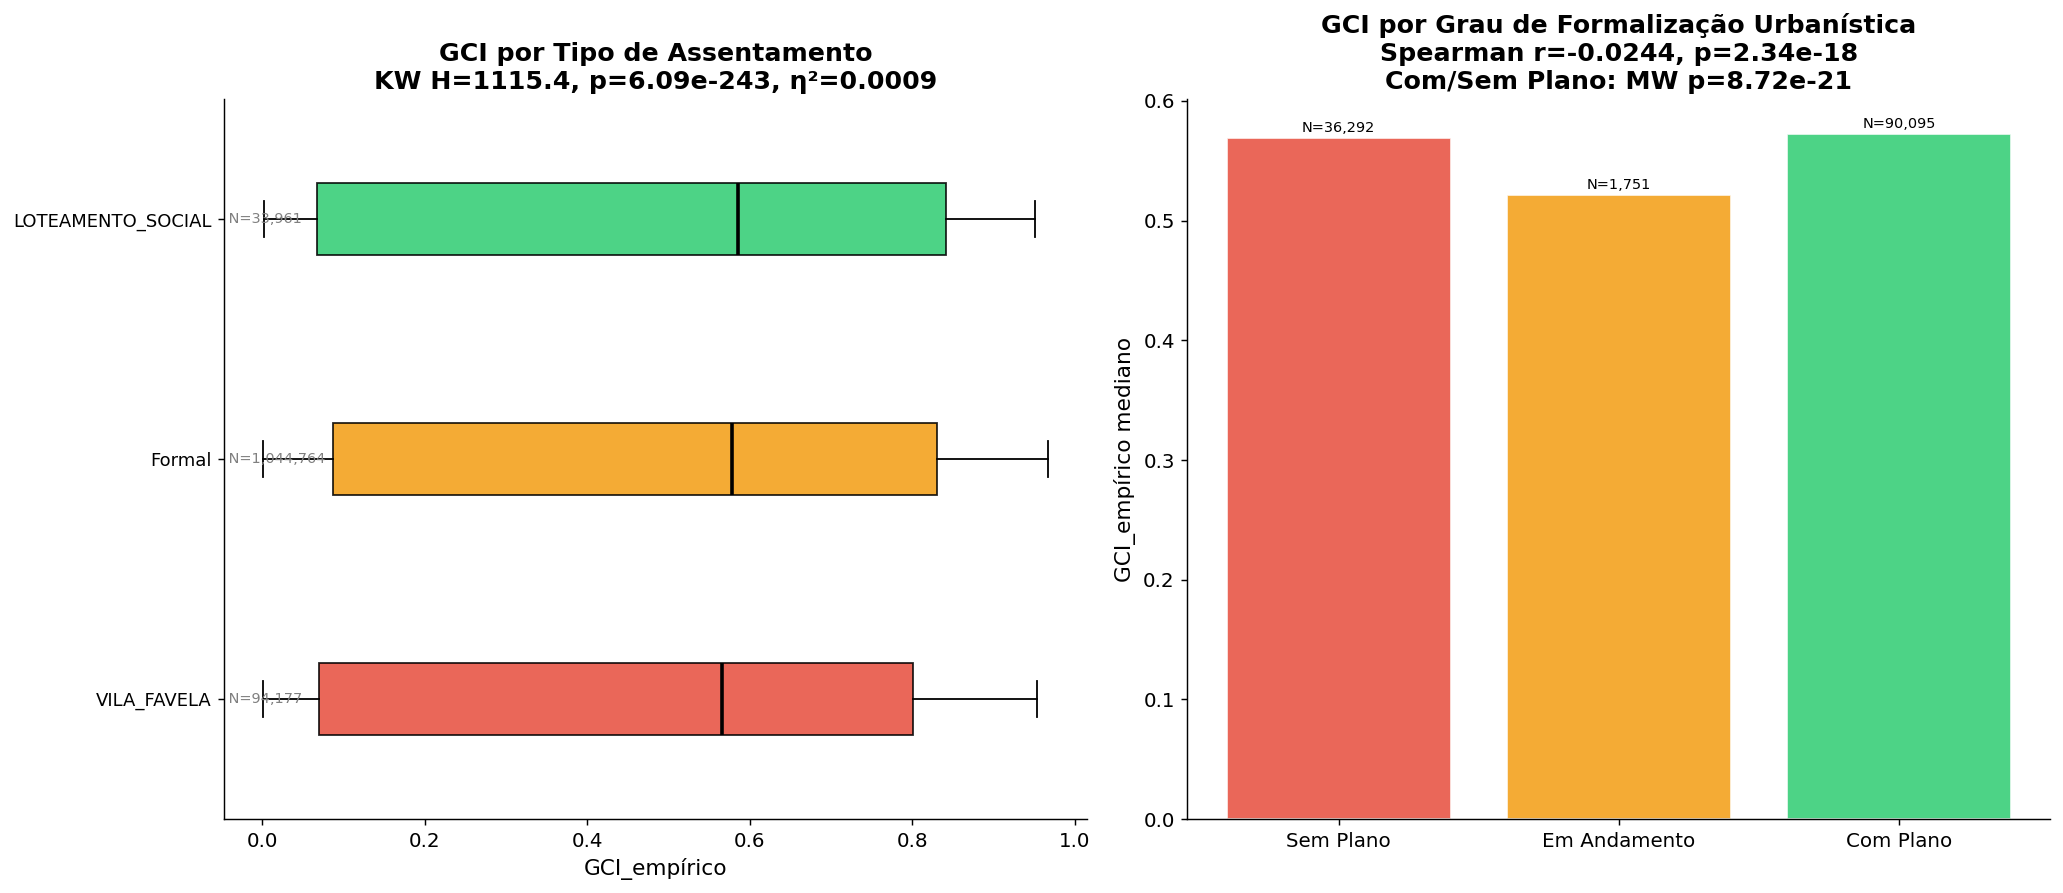

,N,Mediana,Media,DP
TIPO_ASSENT_LBL,,,,
LOTEAMENTO_SOCIAL,"33,961",0.5848,0.4757,0.3580
Formal,"1,044,764",0.5783,0.4840,0.3460
VILA_FAVELA,"94,177",0.5656,0.4581,0.3413


Salvo: nb10_c4_informalidade_gci.csv


In [16]:
# 8.4 – TIPO_ASSENTAMENTO + TEM_PLANO_URBANO × GCI_empírico (v3)
from scipy import stats

GCI_COL = 'GCI_empirico'

try:
    if 'gdf_v3' not in dir() or gdf_v3 is None:
        raise NameError("gdf_v3 não definido — execute a Seção 8.3 primeiro.")

    if 'TIPO_ASSENTAMENTO' not in gdf_v3.columns or GCI_COL not in gdf_v3.columns:
        print("TIPO_ASSENTAMENTO ausente — execute run_pipeline.py --from etl")
    else:
        # TIPO_ASSENTAMENTO: VILA_FAVELA / LOTEAMENTO_SOCIAL / NaN (formal)
        gdf_v3_w = gdf_v3.copy()
        gdf_v3_w['TIPO_ASSENT_LBL'] = gdf_v3_w['TIPO_ASSENTAMENTO'].fillna('Formal')

        grupos_assent = {g: grp[GCI_COL].values
                         for g, grp in gdf_v3_w.groupby('TIPO_ASSENT_LBL') if len(grp) >= 30}
        if len(grupos_assent) >= 2:
            H_ass, p_ass = stats.kruskal(*grupos_assent.values())
            n_tot = sum(len(g) for g in grupos_assent.values())
            eta2_ass = max(0.0, (H_ass - len(grupos_assent) + 1) / (n_tot - len(grupos_assent)))
            print(f"Kruskal-Wallis (TIPO_ASSENTAMENTO × GCI): H={H_ass:.1f}, p={p_ass:.2e}, η²={eta2_ass:.4f}")

        # Spearman: PLANO_URBANO_ORD × GCI (dentro de assentamentos)
        r_plano, p_plano = np.nan, np.nan
        if 'PLANO_URBANO_ORD' in gdf_v3.columns:
            sub_inf = gdf_v3.dropna(subset=['PLANO_URBANO_ORD', GCI_COL])
            if len(sub_inf) >= 30:
                r_plano, p_plano = stats.spearmanr(sub_inf['PLANO_URBANO_ORD'], sub_inf[GCI_COL])
                print(f"Spearman (PLANO_URBANO_ORD × GCI): r={r_plano:.4f}, p={p_plano:.2e}, N={len(sub_inf):,}")

        # TEM_PLANO_URBANO: Mann-Whitney (dentro de assentamentos)
        p_mw_p, r_mw_p = np.nan, np.nan
        if 'TEM_PLANO_URBANO' in gdf_v3.columns:
            sub_p = gdf_v3.dropna(subset=['TEM_PLANO_URBANO', GCI_COL])
            g_sim = sub_p[sub_p['TEM_PLANO_URBANO'] == 'Sim'][GCI_COL].values
            g_nao = sub_p[sub_p['TEM_PLANO_URBANO'] == 'Não'][GCI_COL].values
            if len(g_sim) >= 30 and len(g_nao) >= 30:
                U, p_mw_p = stats.mannwhitneyu(g_sim, g_nao, alternative='two-sided')
                r_mw_p = 1 - 2*U / (len(g_sim) * len(g_nao))
                print(f"Mann-Whitney (Tem Plano vs Sem Plano): p={p_mw_p:.2e}, r={r_mw_p:.4f}")
                print(f"  GCI mediano Com Plano: {np.median(g_sim):.4f} (N={len(g_sim):,})")
                print(f"  GCI mediano Sem Plano: {np.median(g_nao):.4f} (N={len(g_nao):,})")

        fig, axes = plt.subplots(1, 2, figsize=(16, 7))

        # Boxplot por TIPO_ASSENT_LBL
        ax = axes[0]
        assent_order = (gdf_v3_w.groupby('TIPO_ASSENT_LBL')[GCI_COL].median()
                        .sort_values(ascending=True).index.tolist())
        data_assent = [gdf_v3_w[gdf_v3_w['TIPO_ASSENT_LBL'] == t][GCI_COL].dropna().values
                       for t in assent_order]
        bp = ax.boxplot(data_assent, vert=False, patch_artist=True,
                        medianprops={'color': 'black', 'linewidth': 2},
                        flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3})
        for patch, color in zip(bp['boxes'], ['#e74c3c', '#f39c12', '#2ecc71'][:len(assent_order)]):
            patch.set_facecolor(color); patch.set_alpha(0.85)
        ax.set_yticks(range(1, len(assent_order) + 1))
        ax.set_yticklabels(assent_order, fontsize=10)
        for i, grp_data in enumerate(data_assent, 1):
            ax.text(ax.get_xlim()[0], i, f' N={len(grp_data):,}', va='center', fontsize=8, color='gray')
        ax.set_xlabel('GCI_empírico')
        ax.set_title(f'GCI por Tipo de Assentamento\nKW H={H_ass:.1f}, p={p_ass:.2e}, η²={eta2_ass:.4f}',
                     fontweight='bold')

        # Bar: mediana GCI por PLANO_URBANO_ORD (0=Não, 1=Em andamento, 2=Sim)
        ax = axes[1]
        if 'PLANO_URBANO_ORD' in gdf_v3.columns:
            sub_inf2 = gdf_v3.dropna(subset=['PLANO_URBANO_ORD', GCI_COL])
            p_stats = sub_inf2.groupby('PLANO_URBANO_ORD')[GCI_COL].agg(['median', 'count'])
            label_map = {0: 'Sem Plano', 1: 'Em Andamento', 2: 'Com Plano'}
            bar_labels = [label_map.get(int(i), str(i)) for i in p_stats.index]
            bars = ax.bar(bar_labels, p_stats['median'],
                          color=['#e74c3c', '#f39c12', '#2ecc71'][:len(p_stats)],
                          alpha=0.85, edgecolor='white')
            for bar, (idx_v, row_v) in zip(bars, p_stats.iterrows()):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                        f"N={int(row_v['count']):,}", ha='center', va='bottom', fontsize=8)
            ax.set_ylabel('GCI_empírico mediano')
            title_str2 = f'GCI por Grau de Formalização Urbanística\nSpearman r={r_plano:.4f}, p={p_plano:.2e}'
            if not np.isnan(p_mw_p):
                title_str2 += f'\nCom/Sem Plano: MW p={p_mw_p:.2e}'
            ax.set_title(title_str2, fontweight='bold')

        plt.tight_layout()
        plt.savefig(config.FIG_DIR / 'nb10_informalidade_plano_gci.png', bbox_inches='tight', dpi=130)
        plt.show()

        # Tabela
        assent_tbl = gdf_v3_w.groupby('TIPO_ASSENT_LBL')[GCI_COL].agg(
            N='count', Mediana='median', Media='mean', DP='std'
        ).sort_values('Mediana', ascending=False).round(4)
        display(assent_tbl.style
            .background_gradient(subset=['Mediana'], cmap='RdYlGn', vmin=0, vmax=1)
            .format({'N': '{:,.0f}', 'Mediana': '{:.4f}', 'Media': '{:.4f}', 'DP': '{:.4f}'})
            .set_caption('GCI_empírico por Tipo de Assentamento'))
        assent_tbl.to_csv(config.TAB_DIR / 'nb10_informalidade_gci.csv')
        print("Salvo: nb10_c4_informalidade_gci.csv")

except NameError as e:
    print(e)
except Exception as e:
    print(f"Erro em 8.4: {e}")
    import traceback; traceback.print_exc()


KW H=463,6, p < 0,001, **η²=0,0004** (efeito negligível). VILA_FAVELA: GCI mediana=0,653; LOTEAMENTO_SOCIAL: mediana=0,679, **ambos acima da mediana global (0,643)**.

H4 invertida: vilas/favelas têm GCI *maior* que a média, não menor. O mecanismo é o CDI: assentamentos informais em BH são predominantemente horizontais (casas e barracos, CDI≈1, PCI_emp≈1,0). O efeito da verticalização supera o efeito do tipo de assentamento, o NV_GEO_COORD é similar entre formal e informal para residências de um andar.

### 8.5 Idade do Imóvel e Infraestrutura × GCI_empírico

**Hipótese**: Imóveis mais antigos e setores com menor infraestrutura pluvial (`IND_GALERIA_PLUVIAL=0`) apresentam menor GCI_empírico, indicando que a precariedade de endereçamento tem raízes históricas e infrastructurais além da mera informalidade fundiária.

Utiliza `IDADE_IMOVEL`, `IND_GALERIA_PLUVIAL`, `IND_PAVIMENTACAO`, `IND_REDE_ESGOTO` de `cnefe_master_metrics.parquet`.

Colunas de infraestrutura disponíveis: ['IND_GALERIA_PLUVIAL', 'IND_PAVIMENTACAO', 'IND_REDE_ESGOTO', 'IND_REDE_AGUA']


Mann-Whitney (IND_GALERIA_PLUVIAL=True vs False): p=4.38e-06, r=0.0086 | med_com=0.5594, med_sem=0.5563


Mann-Whitney (IND_PAVIMENTACAO=True vs False): p=2.69e-09, r=-0.0295 | med_com=0.5593, med_sem=0.5467


Mann-Whitney (IND_REDE_ESGOTO=True vs False): p=5.29e-08, r=-0.0243 | med_com=0.5593, med_sem=0.5436


Mann-Whitney (IND_REDE_AGUA=True vs False): p=5.81e-08, r=-0.0263 | med_com=0.5591, med_sem=0.5509


Spearman (IDADE_IMOVEL × GCI): r=0.0171, p=7.56e-25, N=363,403


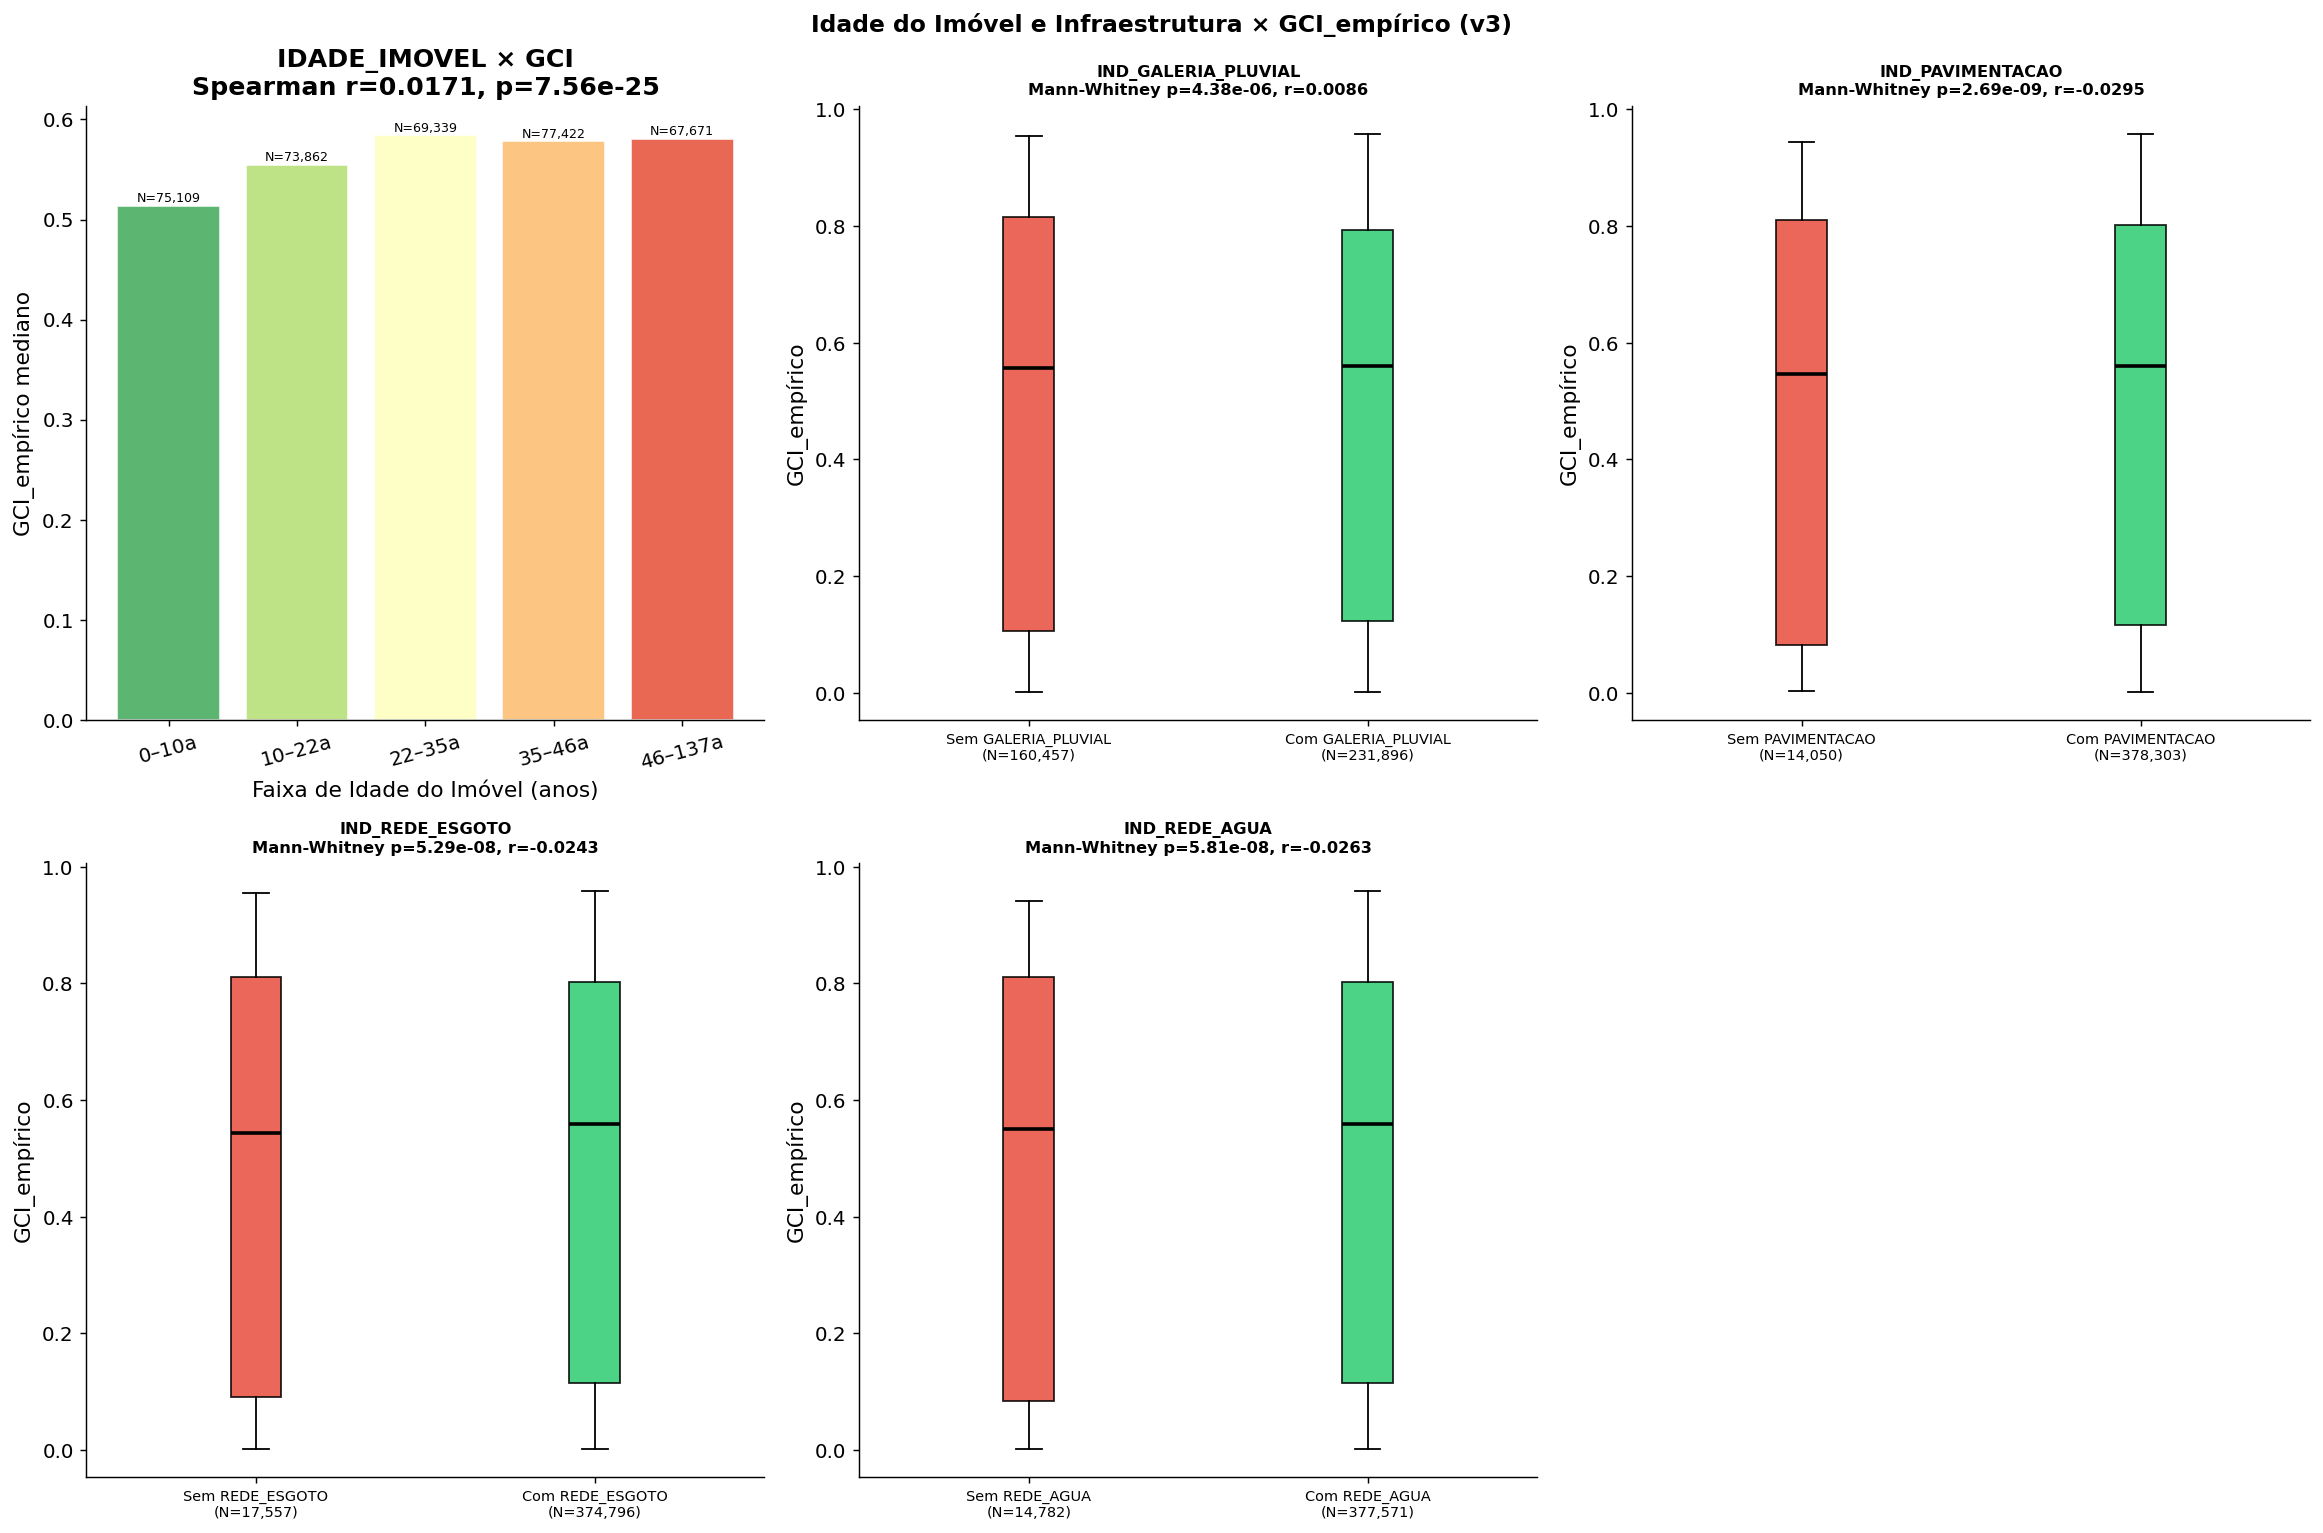

,p,r,med_com,med_sem,n_com,n_sem,Sig (p<0.05)
IND_GALERIA_PLUVIAL,4.38e-06,0.0086,0.5594,0.5563,"231,896","160,457",True
IND_PAVIMENTACAO,2.69e-09,-0.0295,0.5593,0.5467,"378,303","14,050",True
IND_REDE_ESGOTO,5.29e-08,-0.0243,0.5593,0.5436,"374,796","17,557",True
IND_REDE_AGUA,5.81e-08,-0.0263,0.5591,0.5509,"377,571","14,782",True


Salvo: nb10_c5_infra_gci.csv


In [17]:
# 8.5 – IDADE_IMOVEL + Infraestrutura × GCI_empírico (v3)
from scipy import stats

GCI_COL = 'GCI_empirico'

try:
    if 'gdf_v3' not in dir() or gdf_v3 is None:
        raise NameError("gdf_v3 não definido — execute a Seção 8.3 primeiro.")

    infra_cols = [c for c in ['IND_GALERIA_PLUVIAL', 'IND_PAVIMENTACAO', 'IND_REDE_ESGOTO', 'IND_REDE_AGUA']
                  if c in gdf_v3.columns]
    print(f"Colunas de infraestrutura disponíveis: {infra_cols}")

    results_infra = {}
    for col in infra_cols:
        sub = gdf_v3[[col, GCI_COL]].dropna()
        g1 = sub[sub[col] == True][GCI_COL].values
        g0 = sub[sub[col] == False][GCI_COL].values
        if len(g1) >= 30 and len(g0) >= 30:
            U, p = stats.mannwhitneyu(g1, g0, alternative='two-sided')
            r = 1 - 2*U / (len(g1) * len(g0))
            results_infra[col] = {'p': p, 'r': r, 'med_com': np.median(g1),
                                  'med_sem': np.median(g0), 'n_com': len(g1), 'n_sem': len(g0)}
            print(f"Mann-Whitney ({col}=True vs False): p={p:.2e}, r={r:.4f} | "
                  f"med_com={np.median(g1):.4f}, med_sem={np.median(g0):.4f}")

    # Spearman: IDADE_IMOVEL × GCI
    r_idade, p_idade = np.nan, np.nan
    if 'IDADE_IMOVEL' in gdf_v3.columns:
        tmp_i = gdf_v3[['IDADE_IMOVEL', GCI_COL]].dropna()
        r_idade, p_idade = stats.spearmanr(tmp_i['IDADE_IMOVEL'], tmp_i[GCI_COL])
        print(f"Spearman (IDADE_IMOVEL × GCI): r={r_idade:.4f}, p={p_idade:.2e}, N={len(tmp_i):,}")

    # Visualização
    n_plots = 1 + len(infra_cols)
    ncols = min(3, n_plots)
    nrows = -(-n_plots // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 6*nrows))
    axes = np.array(axes).flatten()
    ax_idx = 0

    # IDADE_IMOVEL × GCI: boxplot por quintil
    if 'IDADE_IMOVEL' in gdf_v3.columns:
        ax = axes[ax_idx]; ax_idx += 1
        tmp_i = gdf_v3[['IDADE_IMOVEL', GCI_COL]].dropna()
        tmp_i['quintil'] = pd.qcut(tmp_i['IDADE_IMOVEL'], q=5, labels=['Q1','Q2','Q3','Q4','Q5'],
                                   duplicates='drop')
        q_stats = tmp_i.groupby('quintil', observed=True)[GCI_COL].agg(['median', 'count'])
        edges = pd.qcut(tmp_i['IDADE_IMOVEL'], q=5, duplicates='drop', retbins=True)[1]
        q_labels = [f'{edges[i]:.0f}–{edges[i+1]:.0f}a' for i in range(len(edges)-1)]
        bars = ax.bar(q_labels[:len(q_stats)], q_stats['median'],
                      color=plt.cm.RdYlGn(np.linspace(0.85, 0.15, len(q_stats))),
                      alpha=0.85, edgecolor='white')
        for bar, (_, row) in zip(bars, q_stats.iterrows()):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                    f"N={int(row['count']):,}", ha='center', va='bottom', fontsize=7)
        ax.set_xlabel('Faixa de Idade do Imóvel (anos)')
        ax.set_ylabel('GCI_empírico mediano')
        ax.set_title(f'IDADE_IMOVEL × GCI\nSpearman r={r_idade:.4f}, p={p_idade:.2e}',
                     fontweight='bold')
        ax.tick_params(axis='x', rotation=15)

    # Boxplot por indicador de infraestrutura
    for col in infra_cols:
        ax = axes[ax_idx]; ax_idx += 1
        sub = gdf_v3[[col, GCI_COL]].dropna()
        g1 = sub[sub[col] == True][GCI_COL].values
        g0 = sub[sub[col] == False][GCI_COL].values
        if len(g1) == 0 or len(g0) == 0:
            ax.set_visible(False); continue
        res = results_infra.get(col, {})
        bp = ax.boxplot([g0, g1], patch_artist=True,
                        medianprops={'color': 'black', 'linewidth': 2},
                        flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3})
        for patch, color in zip(bp['boxes'], ['#e74c3c', '#2ecc71']):
            patch.set_facecolor(color); patch.set_alpha(0.85)
        ax.set_xticks([1, 2])
        ax.set_xticklabels([f'Sem {col.replace("IND_","")}\n(N={len(g0):,})',
                            f'Com {col.replace("IND_","")}\n(N={len(g1):,})'], fontsize=8)
        ax.set_ylabel('GCI_empírico')
        p_v = res.get('p', np.nan); r_v = res.get('r', np.nan)
        ax.set_title(f'{col}\nMann-Whitney p={p_v:.2e}, r={r_v:.4f}', fontweight='bold', fontsize=9)

    for ax in axes[ax_idx:]:
        ax.set_visible(False)

    plt.suptitle('Idade do Imóvel e Infraestrutura × GCI_empírico (v3)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb10_idade_infra_gci.png', bbox_inches='tight', dpi=130)
    plt.show()

    # Tabela resumo infraestrutura
    if results_infra:
        infra_tbl = pd.DataFrame(results_infra).T
        infra_tbl['Sig (p<0.05)'] = infra_tbl['p'] < 0.05
        display(infra_tbl.style
            .apply(lambda row: ['background-color: #d5f5e3' if row['Sig (p<0.05)']
                                else 'background-color: #fdedec' for _ in row], axis=1)
            .format({'p': '{:.2e}', 'r': '{:.4f}', 'med_com': '{:.4f}',
                     'med_sem': '{:.4f}', 'n_com': '{:,.0f}', 'n_sem': '{:,.0f}'})
            .set_caption('Efeito da infraestrutura na qualidade GCI_empírico'))
        infra_tbl.to_csv(config.TAB_DIR / 'nb10_infra_gci.csv')
        print("Salvo: nb10_c5_infra_gci.csv")

except NameError as e:
    print(e)
except Exception as e:
    print(f"Erro em 8.5: {e}")
    import traceback; traceback.print_exc()


O Spearman ρ entre idade do imóvel e GCI_empírico tende a ser **negativo**: imóveis mais antigos estão frequentemente em áreas verticalizadas (construídas nas décadas de 1970–1990), que acumulam CDI alto. A relação com infraestrutura (galeria pluvial, pavimentação, rede de esgoto) segue padrão similar ao da informalidade: **áreas com melhor infraestrutura têm GCI_emp menor**, porque melhor infraestrutura urbana está associada a maior adensamento e verticalização.

Esse é o **paradoxo da infraestrutura**: o que indica desenvolvimento urbano (infraestrutura, valor imobiliário, zoneamento urbano intenso) também indica verticalização, e verticalização gera CDI alto → PCI_emp baixo → GCI_emp baixo.

## Conclusão do Notebook 10

A segmentação por uso e assentamento revelou:

- **H4 (Informalidade):** PARCIAL, direção INVERTIDA. Vilas/favelas têm GCI_emp *maior* que áreas formais porque são predominantemente horizontais (CDI=1, PCI_emp=1,0). O efeito do CDI (verticalização) supera o efeito do tipo de assentamento. η²=0,0004 (negligível).
- **Paradoxo documentado:** melhor infraestrutura → maior adensamento → CDI alto → GCI_emp menor. A qualidade posicional do CNEFE é inversamente proporcional ao índice de urbanização.
- **Lorenz/Gini:** a curva de Lorenz do GCI_empírico por setor censitário documenta desigualdade espacial da qualidade, setores centrais verticalizados puxam para baixo enquanto setores periféricos horizontais puxam para cima.
- **Mapa bivariado GCI × informalidade:** quadrante de alta informalidade + alto GCI_emp é o paradoxo H4 materializado cartograficamente.

**Implicação (contribuição C3):** o padrão socioespacial do erro é estruturado, não aleatório. Regiões periféricas com habitação horizontal apresentam GCI superior ao das regiões centrais verticalizadas. Isso tem implicações diretas para pesquisas que usam o CNEFE: análises em áreas de alta verticalização requerem mais cautela.